# Interpretability Assessment of Latent Features learned on a single cell reference dataset and applied to a spatial transcriptomics dataset of different Embedding Methods

## Module Imports

In [1]:
import itertools
from dataclasses import dataclass
from typing import Callable, Any, Sequence
import pickle
import mlflow
import scanpy as sc
import nico2_lib as n2l
import matplotlib.pyplot as plt
import numpy as np
from numpy import number
from numpy.typing import NDArray
import polars as pl
import seaborn as sns
from sklearn.neighbors import kneighbors_graph
from experiment import (
    DatasetDimension,
    CelltypeDimension,
    ExperimentResult,
    ModelDimension,
    ResultRecord,
    SampleDimension,
)

/Users/egerc/Documents/Projects/notebook_repository/notebooks/2026-02-17T08-24-52Z/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
benchmark_experiment = mlflow.get_experiment_by_name("Default")
runs = mlflow.search_runs(experiment_ids=[benchmark_experiment.experiment_id])
last_run_id = runs.sort_values("start_time", ascending=False)["run_id"].iloc[0]

2026/02/27 12:09:45 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/27 12:09:45 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/27 12:09:45 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/27 12:09:45 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/27 12:09:45 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/27 12:09:45 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/27 12:09:45 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/27 12:09:45 INFO alembic.runtime.migration: Will assume non-transactional DDL.


In [14]:
last_run_id

'3d06fddb2d8d44e995db040cf1bfe683'

In [152]:
sc.read_h5ad("/Users/egerc/Documents/Projects/notebook_repository/notebooks/2026-02-10T09-07-37Z/data/mouse_small_intestine_sc/mouse_small_intestine_sc.h5ad").obs["cluster"].value_counts()

cluster
Stem/TA                    420
BZE                        325
Lymphatic                  267
Rest B                     234
Goblet                     216
Paneth                     128
Tuft                        90
Macrophage                  89
Plasma                      85
Stroma                      84
MZE                         63
T cell                      54
TZE                         40
cDC/monocyte                40
Blood vasc.                 33
neurons/enteroendocrine     26
Cycling/GC B cell           19
pDC                         16
Glial                       10
Name: count, dtype: int64

In [166]:
query = sc.read_h5ad("/Users/egerc/Documents/Projects/notebook_repository/notebooks/2026-02-10T09-07-37Z/data/mouse_small_intestine_merfish/mouse_small_intestine_merfish.h5ad")


In [167]:
query.obs.columns


Index([], dtype='object')

In [4]:
mlflow.get_run(last_run_id).data.params["dataloader_keys"]

"['small_mouse_intestine_spatial', 'small_mouse_intestine_pseudospatial']"

NameError: name 'mlflow' is not defined

In [102]:
#artifact_path = mlflow.artifacts.download_artifacts(
#    run_id=last_run_id, artifact_path="results.pkl"
#)
artifact_path = "/Users/egerc/Documents/Projects/notebook_repository/notebooks/2026-02-17T08-24-52Z/mlruns/0/18e390537fa8458387a9b0668d677f42/artifacts/results.pkl"
with open(artifact_path, "rb") as f:
    results = pickle.load(f)

## Helpers

Text(0.5, 1.0, 'KMeans Clustering and UMAP Embedding on top 25 PCs')

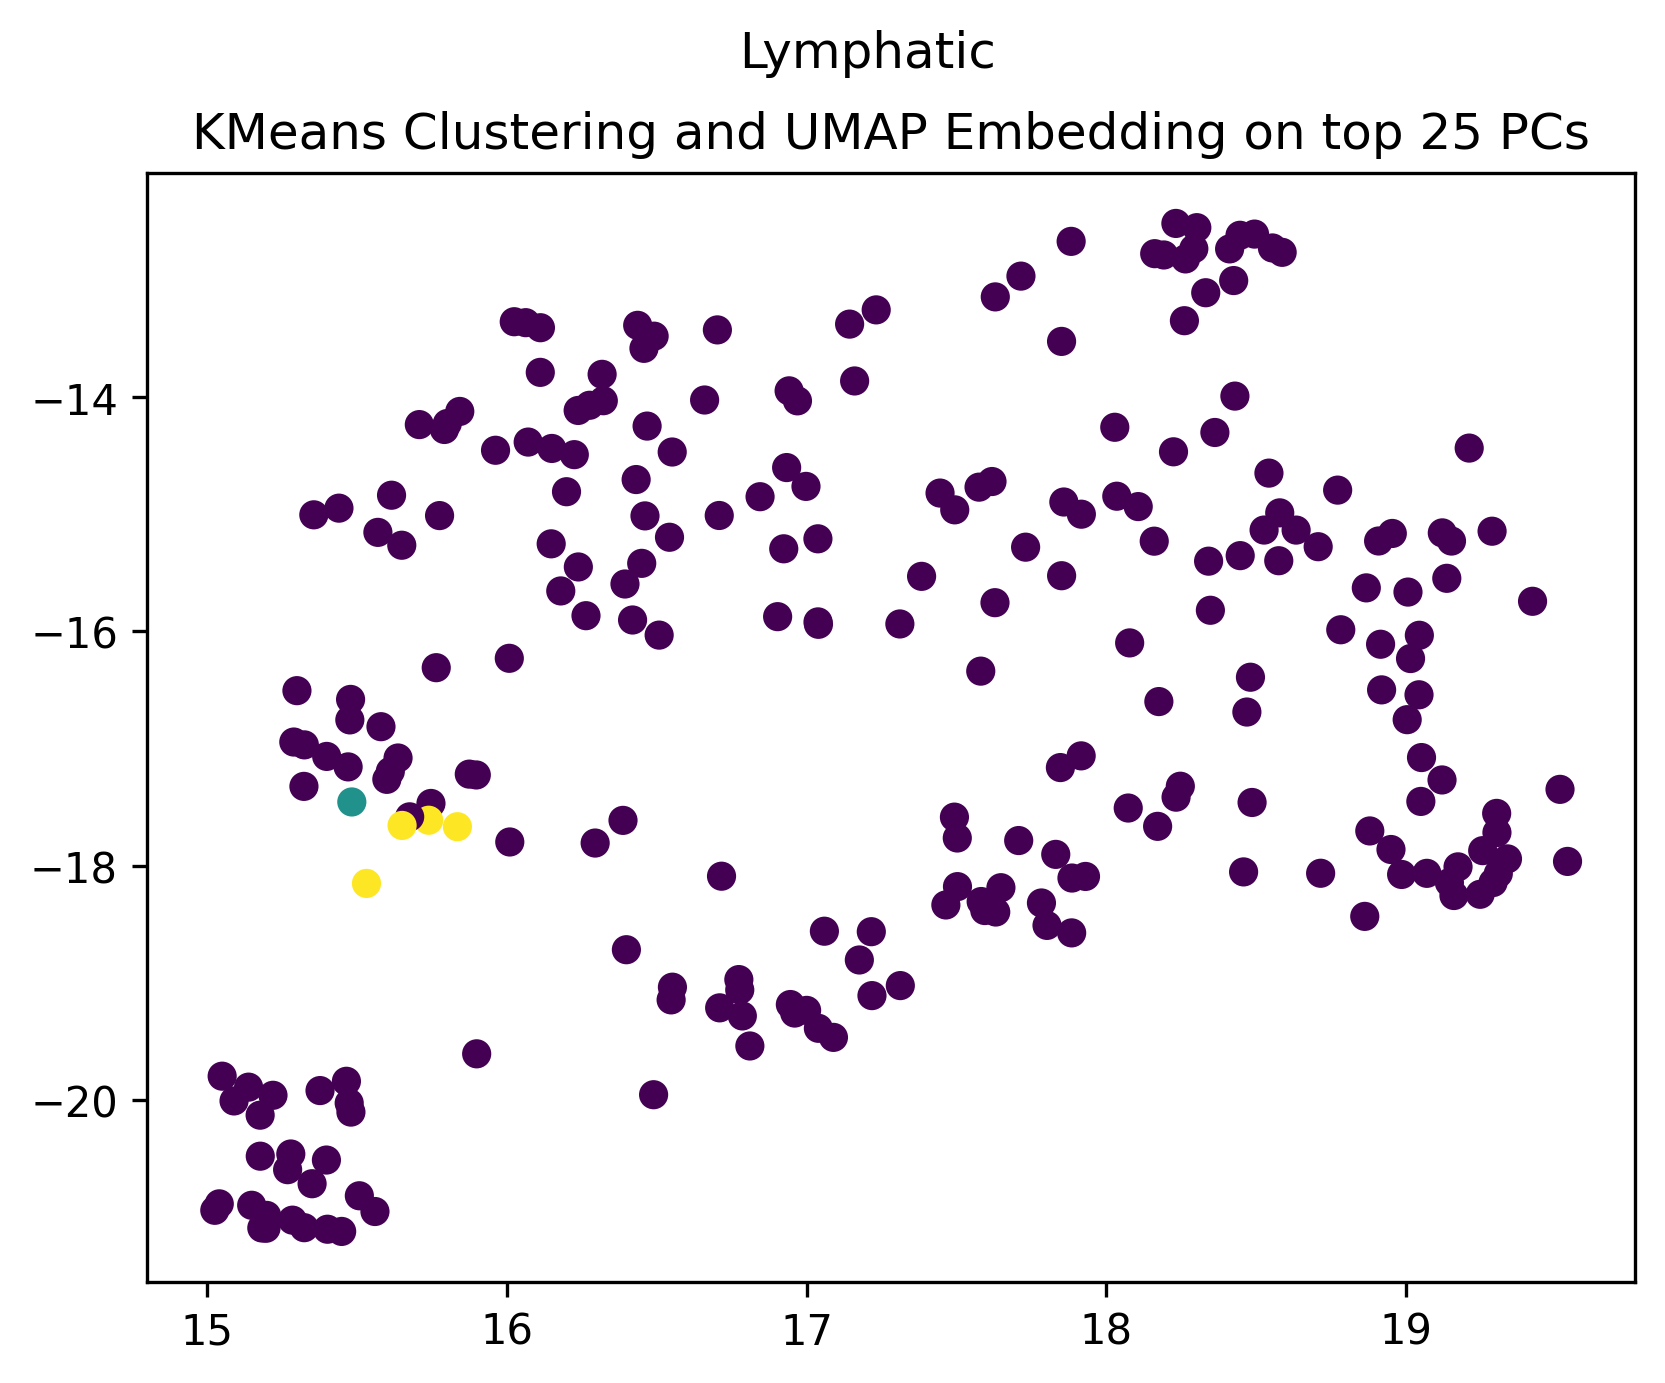

In [103]:
from sklearn.cluster import KMeans

celltype_idx = 4

celltype = results.celltypes[celltype_idx]
clustering = KMeans(n_clusters=3).fit_predict(celltype.pca_embedding)
plt.figure(dpi=300)
plt.scatter(*celltype.umap_embedding.T, c=clustering)
plt.suptitle(celltype.celltype)
plt.title("KMeans Clustering and UMAP Embedding on top 25 PCs")

In [169]:
NumericArray = NDArray[number]
MetricResult = list[dict[str, Any]]
MetricResultFn = Callable[[ResultRecord], MetricResult]


def construct_result_table(
    results: ExperimentResult,
    extract_results_fn: MetricResultFn,
) -> pl.DataFrame:

    rows: MetricResult = []

    for i, result in enumerate(results.results):
        dataset = results.datasets[result.dataset_id]
        celltype = results.celltypes[result.celltype_id]
        sample = results.samples[result.sample_id]
        model = results.models[result.model_id]
        extracted_results = extract_results_fn(result)

        for extracted_result in extracted_results:
            rows.append(
                {
                    **extracted_result,
                    "dataset_name": dataset.dataset_name,
                    "celltype": celltype.celltype,
                    "sample_id": sample.sample_id,
                    "model_name": model.model_name,
                }
            )

    return pl.DataFrame(rows)

In [8]:
def constant_corr(n: int, rho: float):
    corr = np.full((n, n), rho)
    np.fill_diagonal(corr, 1)
    return corr


corr = constant_corr(3, 0.8)


def generate_correlated_latent_embedding(
    n_features: int,
    strength: float,
    n_samples: int,
    rng: np.random.Generator | None = None,
) -> NumericArray:
    rng = rng or np.random.default_rng()
    cov = constant_corr(n_features, strength)
    return rng.multivariate_normal(mean=np.zeros(n_features), cov=cov, size=n_samples)


### Embedding Autocorrelation (Feature<->Feature)

In [140]:
def _create_avg_pairwise_metric_fn(
    metric_fn: Callable[[NumericArray, NumericArray], float],
) -> Callable[[NumericArray], float]:
    """Returns a function that computes the average pairwise metric between feature columns.

    The returned function applies ``metric_fn`` to all unique pairs of columns
    in a 2D array of shape (n_samples, n_features) and returns the mean result.

    Args:
        metric_fn: Function that takes two 1D arrays and returns a float.

    Returns:
        Function that takes a 2D array and returns the average pairwise metric
        across all column pairs."""

    def pairwise_metric_fn(
        features: NumericArray,
    ) -> float:
        eps = 1e-8
        return np.array(
            [metric_fn(a + eps, b + eps) for a, b in itertools.combinations(features.T, 2)]
        ).mean()

    return pairwise_metric_fn


def build_autocorrelation_metric_registry():
    return {
        "pearsonr": _create_avg_pairwise_metric_fn(n2l.mt.pearson_metric),
        "spearmanr": _create_avg_pairwise_metric_fn(n2l.mt.spearman_metric),
        "cosine_similarity": _create_avg_pairwise_metric_fn(
            n2l.mt.cosine_similarity_metric
        ),
    }


def make_autocorrelation_metric_evaluator(
    metric_registry: dict[str, Callable[[NDArray[number]], float]],
) -> MetricResultFn:
    def evaluate_autocorrelation_metrics(
        result: ResultRecord,
    ) -> MetricResult:
        return [
            {
                "metric_name": metric_name,
                "global_model_result": metric_fn(result.global_model_embedding),
                "celltype_model_result": metric_fn(result.celltype_model_embedding),
            }
            for metric_name, metric_fn in metric_registry.items()
        ]

    return evaluate_autocorrelation_metrics

In [10]:
def plot_embeddings_with_metrics(
    n_features: int,
    strength: float,
    n_samples: int,
    metrics_registry: dict[str, Callable[[NumericArray], float]],
    rng: np.random.Generator | None = None,
):
    rng = rng or np.random.default_rng()

    embedding = generate_correlated_latent_embedding(
        n_features, strength, n_samples, rng
    )
    df = pl.DataFrame(embedding)

    metrics_results = {name: fn(embedding) for name, fn in metrics_registry.items()}
    metrics_text = "\n".join([f"{k}: {v:.2f}" for k, v in metrics_results.items()])

    g = sns.PairGrid(df)
    g.map(sns.scatterplot, s=15, alpha=0.6)

    ax = g.axes[0, -1]
    ax.text(
        1.05,
        0.5,
        metrics_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="center",
        bbox=dict(boxstyle="round,pad=0.3", alpha=0.2),
    )

    g.fig.suptitle(f"Correlation Strength = {strength}", fontsize=14, y=1.02)
    plt.show()

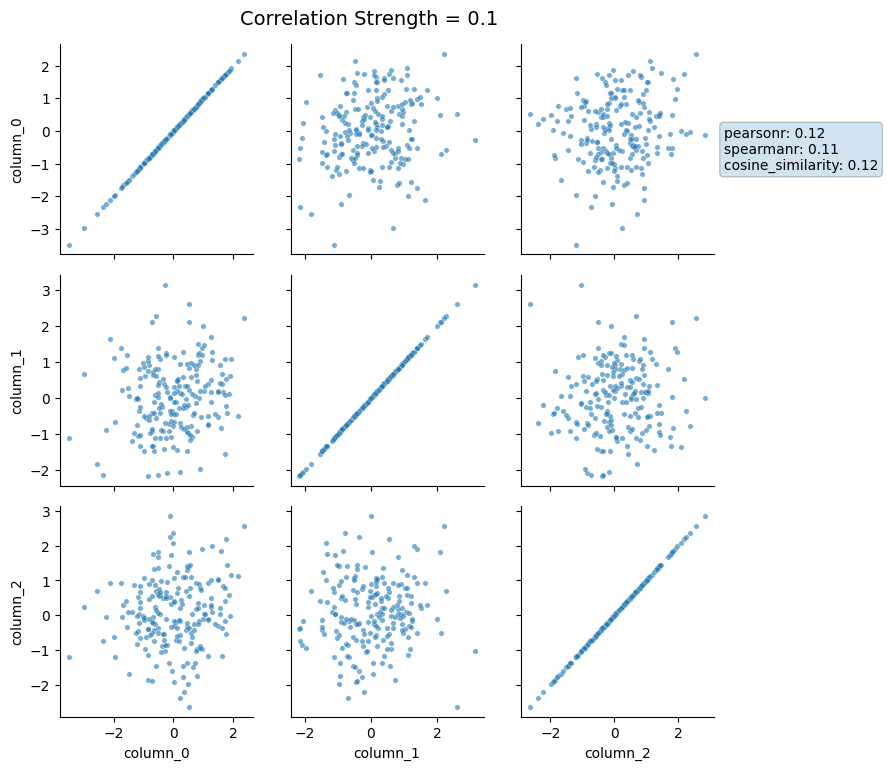

In [141]:
plot_embeddings_with_metrics(
    3,
    0.1,
    200,
    build_autocorrelation_metric_registry(),
    np.random.default_rng(0),
)

In [170]:
autocorrelation_df = construct_result_table(
    results,
    extract_results_fn=make_autocorrelation_metric_evaluator(
        build_autocorrelation_metric_registry()
    ),
).unpivot(
    index=["metric_name", "dataset_name", "celltype", "sample_id", "model_name"],
    variable_name="model_prediction_scope",
    value_name="autocorrelation_score",
)
autocorrelation_df

metric_name,dataset_name,celltype,sample_id,model_name,model_prediction_scope,autocorrelation_score
str,str,str,i64,str,str,f64
"""pearsonr""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_result""",0.259
"""spearmanr""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_result""",0.503514
"""cosine_similarity""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_result""",0.470776
"""pearsonr""","""small_mouse_intestine_spatial""","""Blood vasc.""",0,"""NMF_3""","""global_model_result""",0.174804
"""spearmanr""","""small_mouse_intestine_spatial""","""Blood vasc.""",0,"""NMF_3""","""global_model_result""",0.528333
…,…,…,…,…,…,…
"""spearmanr""","""small_mouse_intestine_pseudosp…","""cDC/monocyte""",9,"""SCVI_3""","""celltype_model_result""",-0.221554
"""cosine_similarity""","""small_mouse_intestine_pseudosp…","""cDC/monocyte""",9,"""SCVI_3""","""celltype_model_result""",-0.316563
"""pearsonr""","""small_mouse_intestine_pseudosp…","""neurons/enteroendocrine""",9,"""SCVI_3""","""celltype_model_result""",0.781988


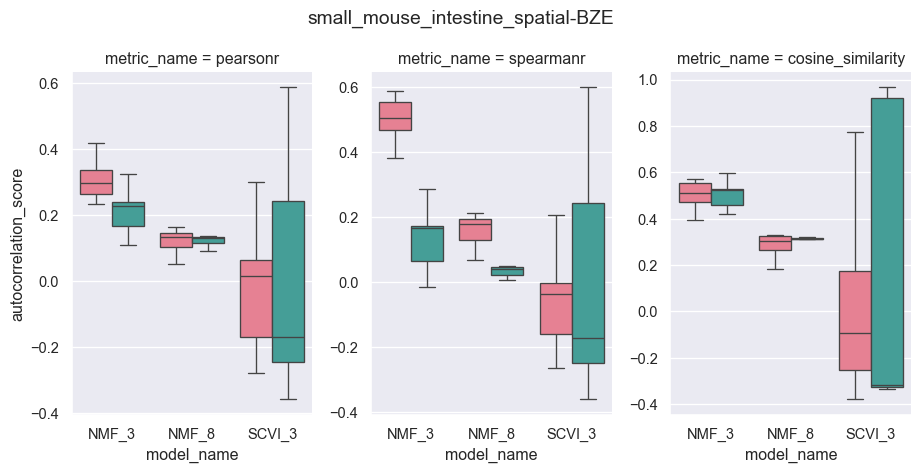

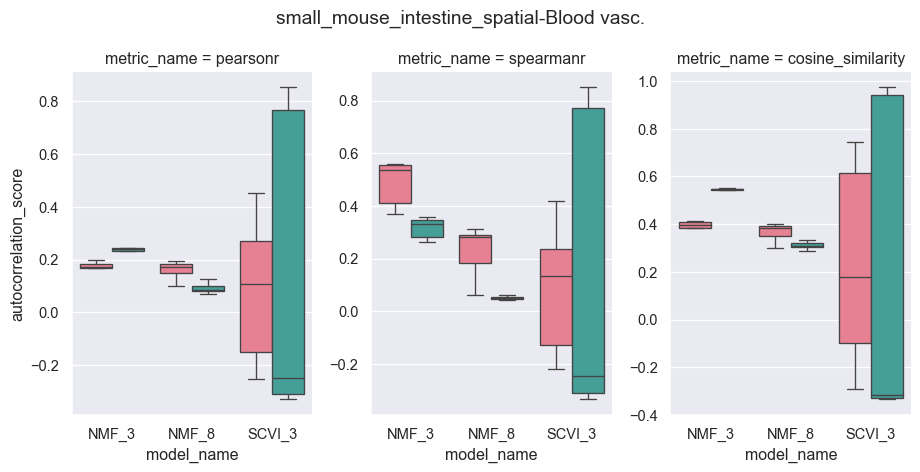

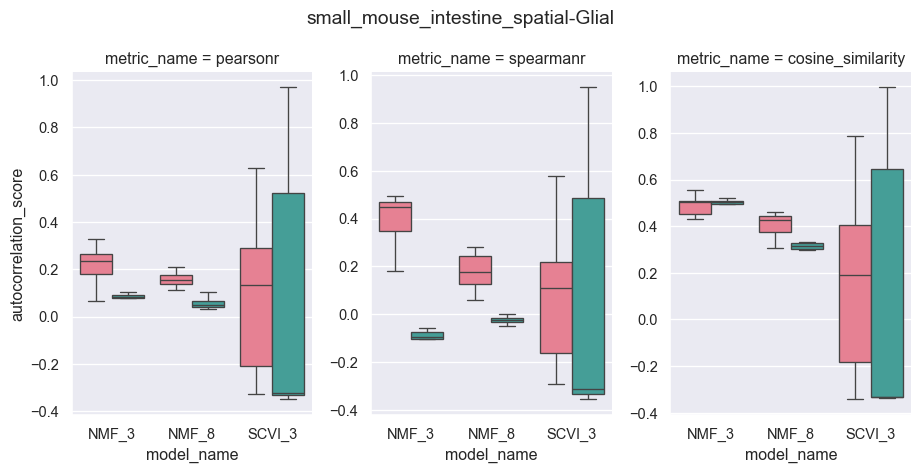

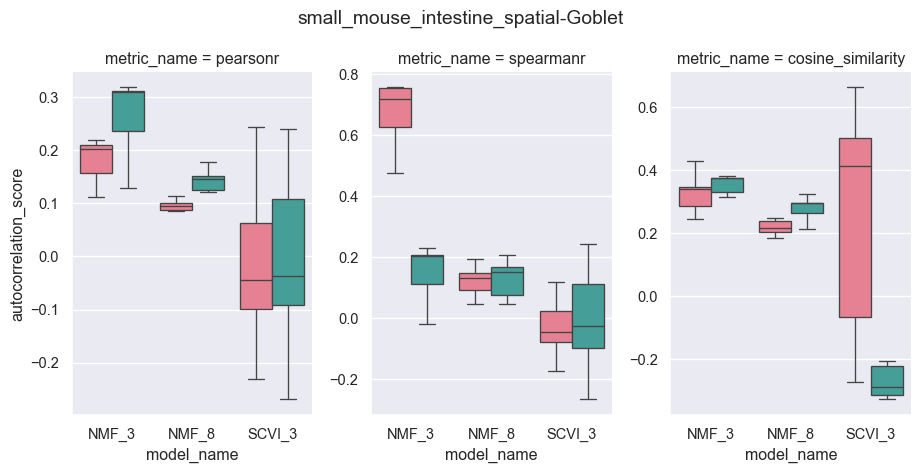

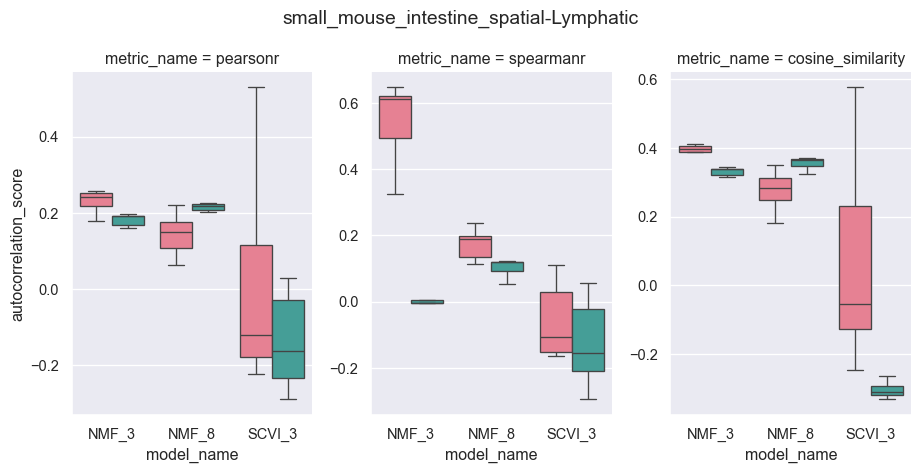

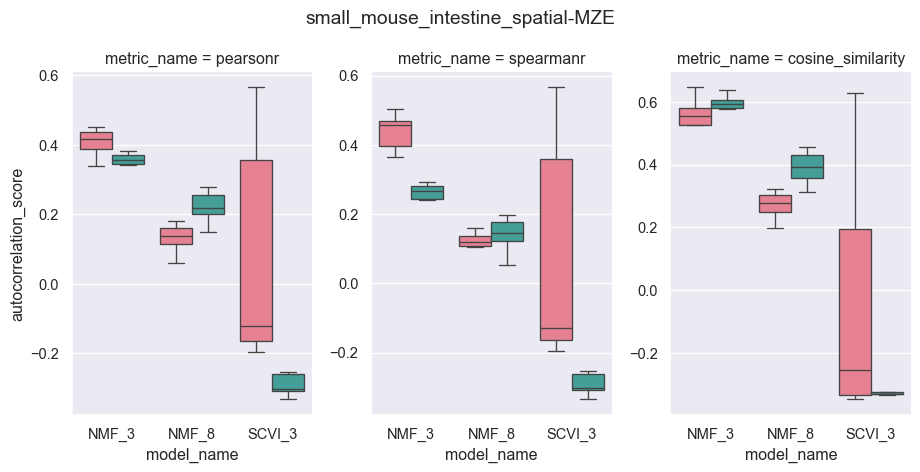

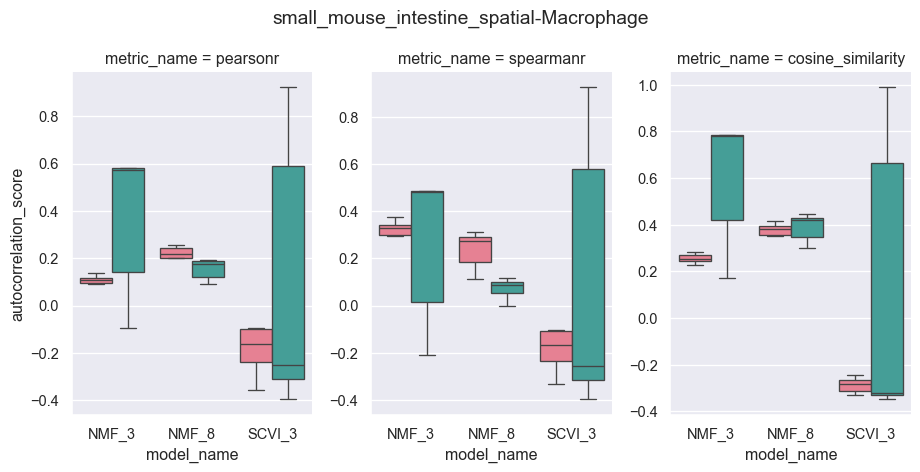

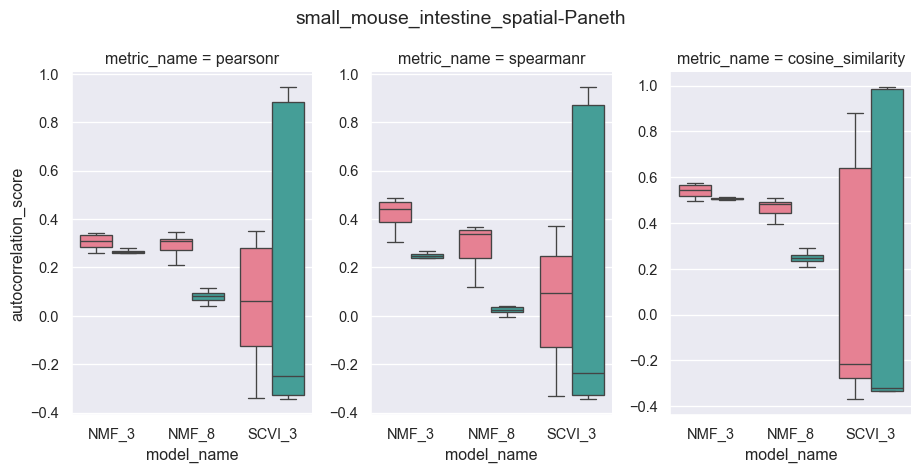

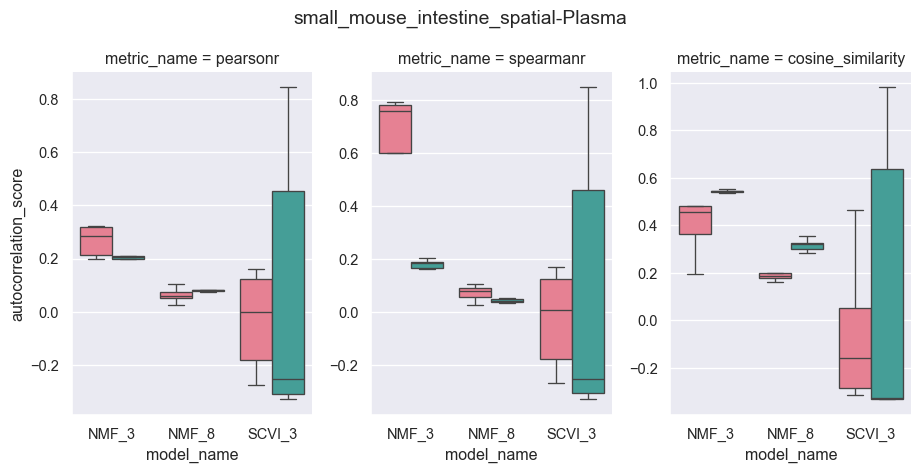

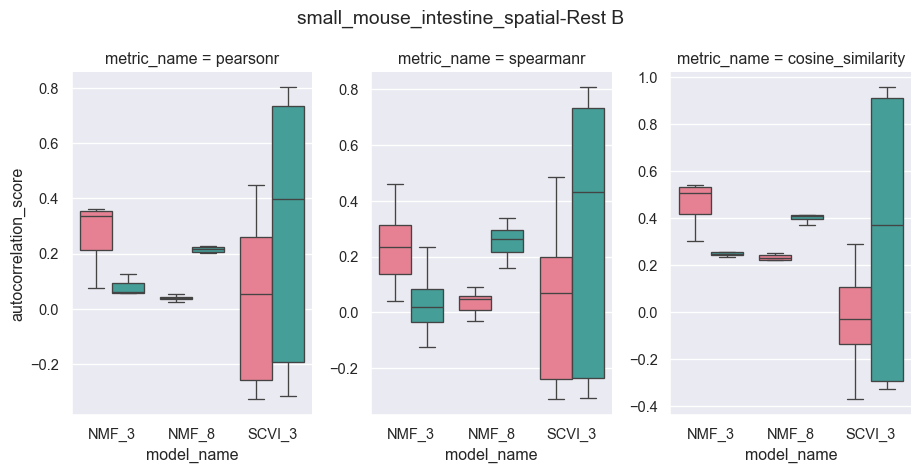

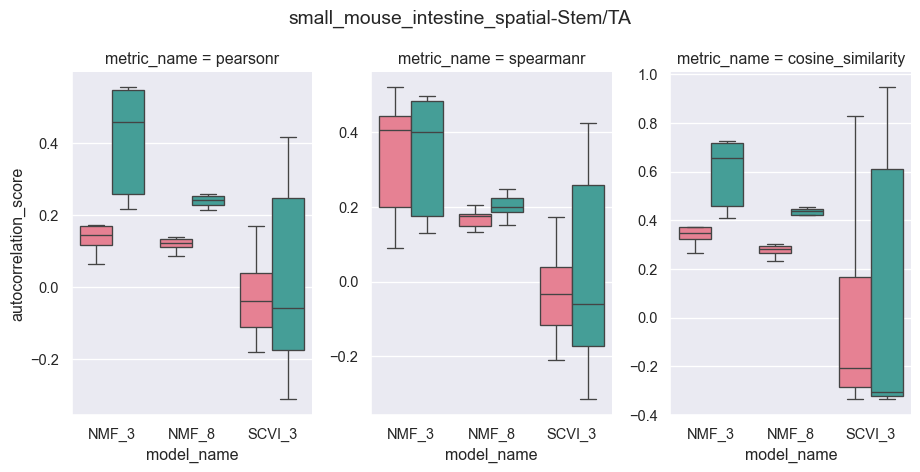

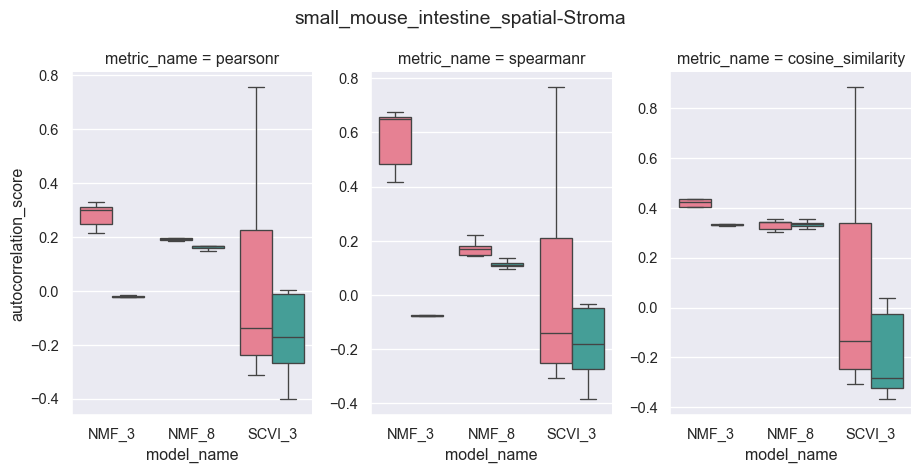

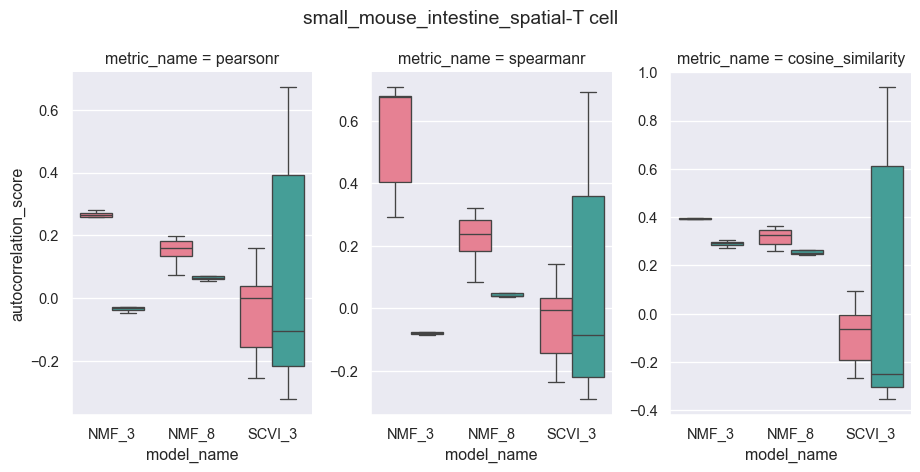

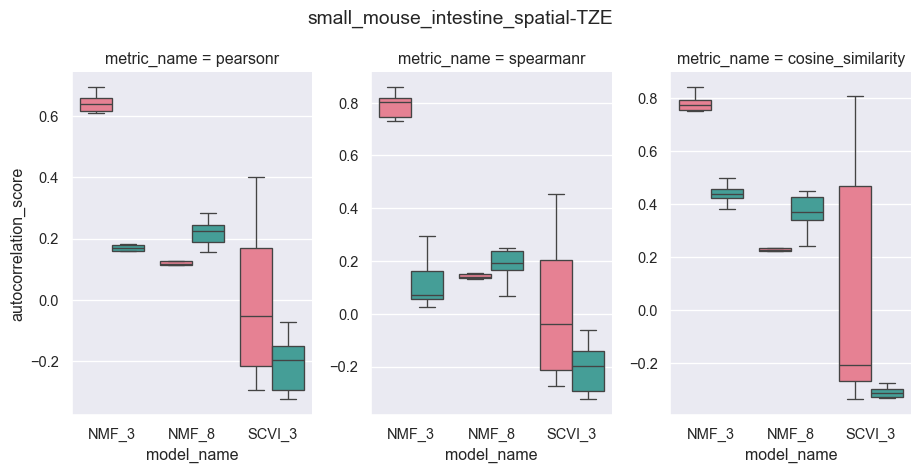

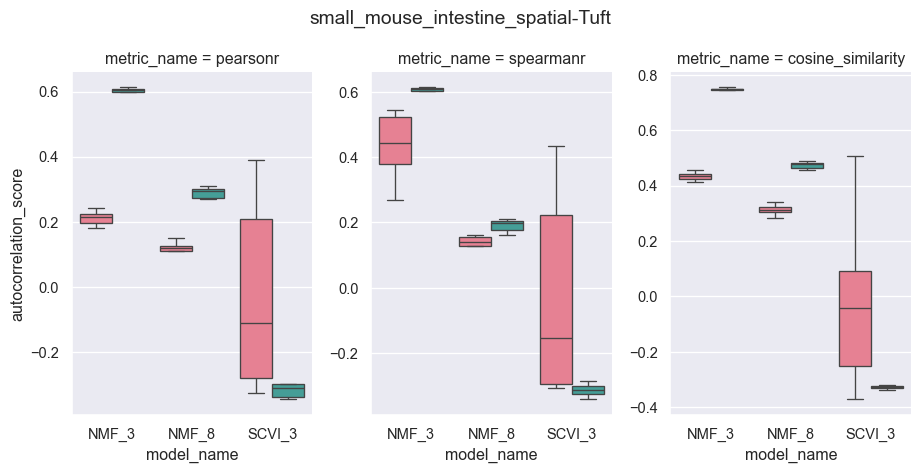

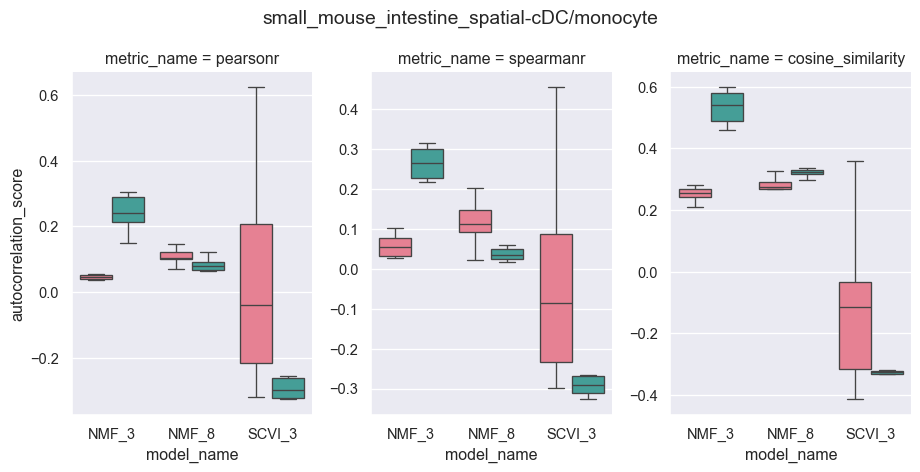

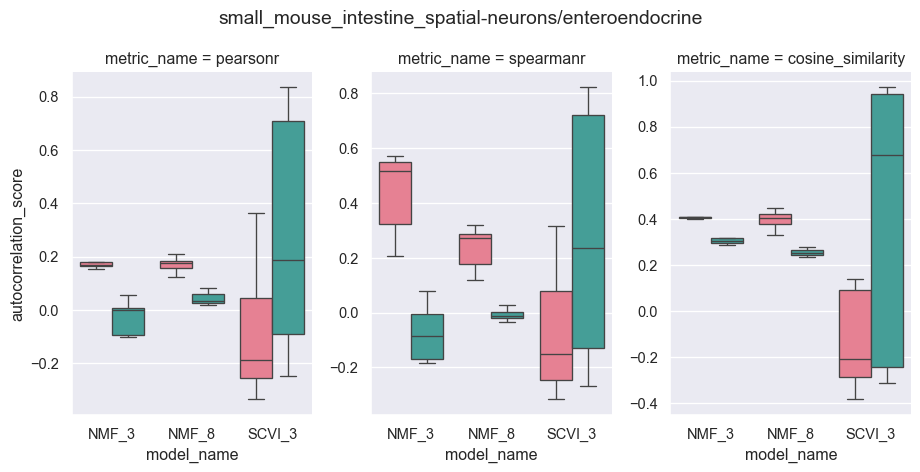

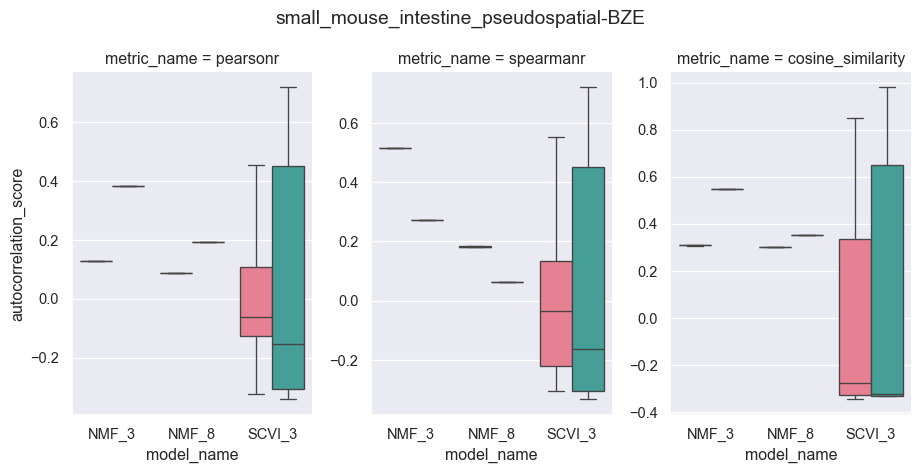

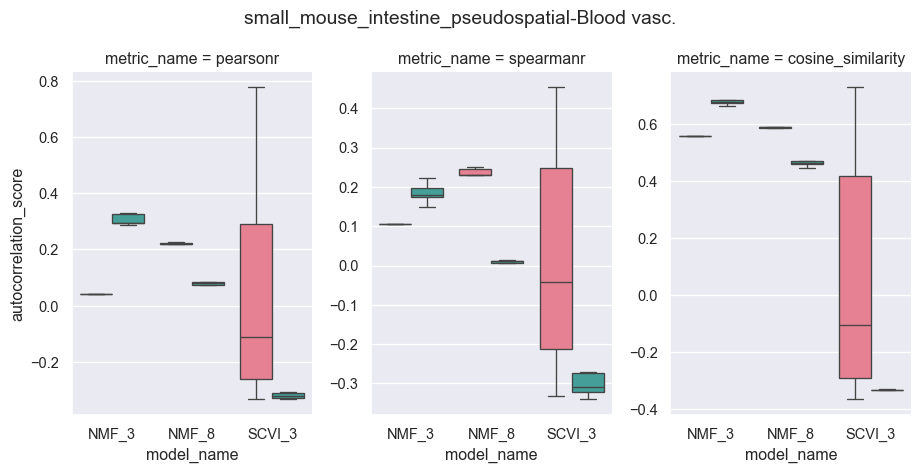

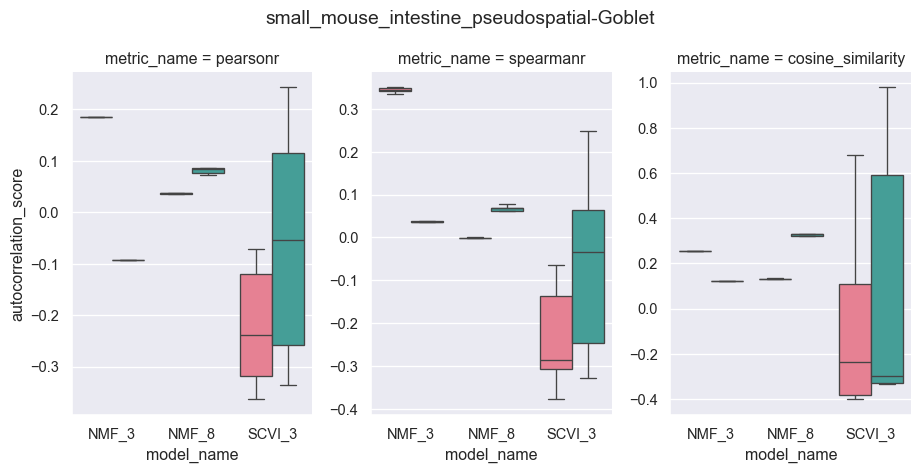

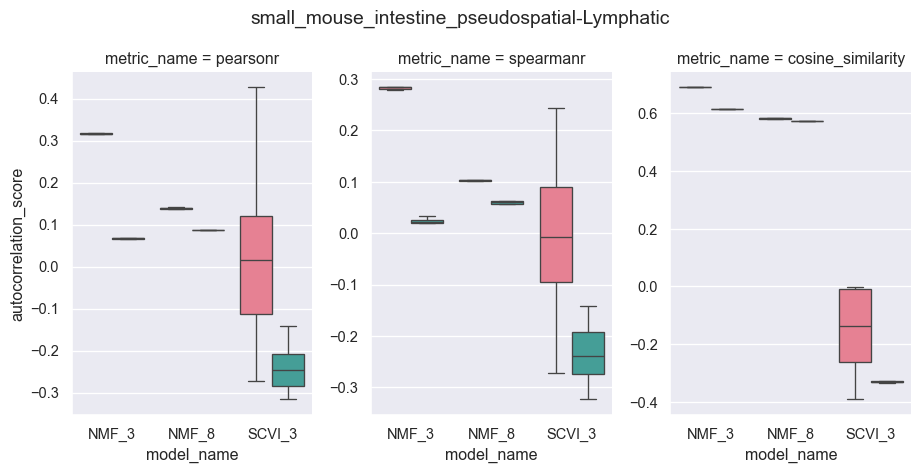

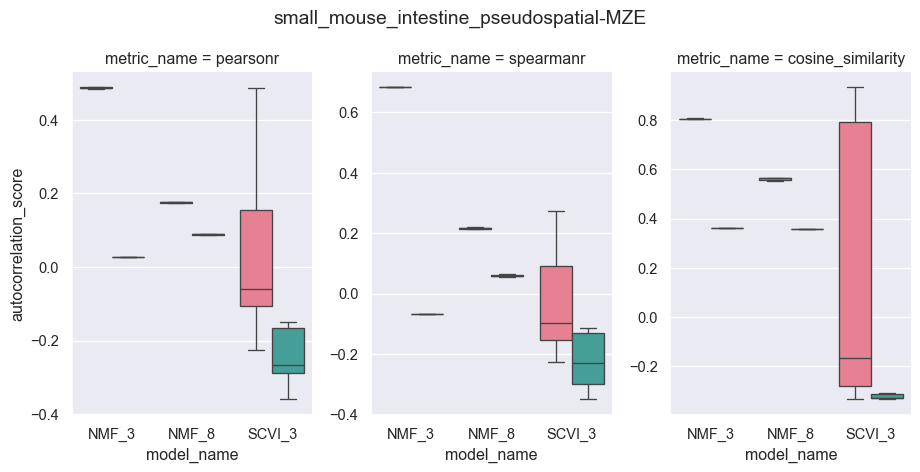

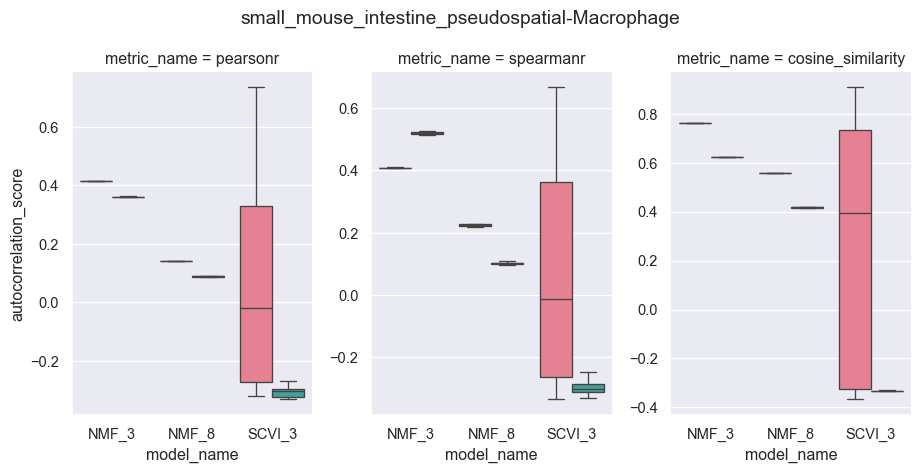

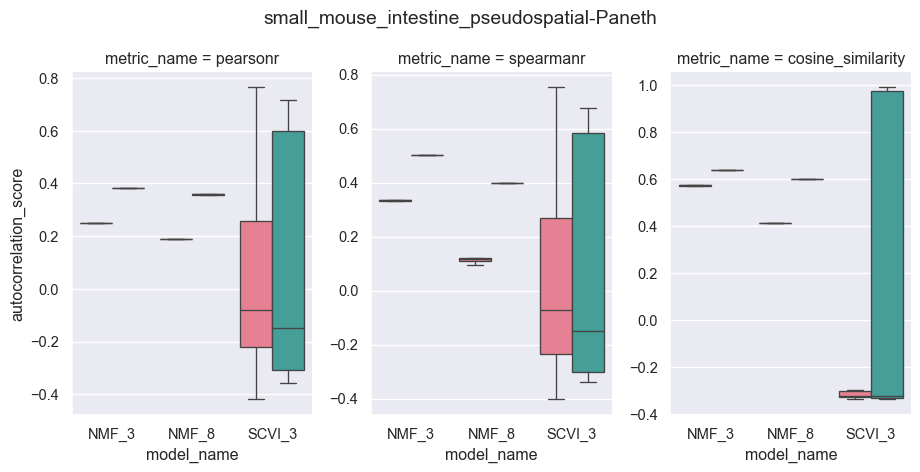

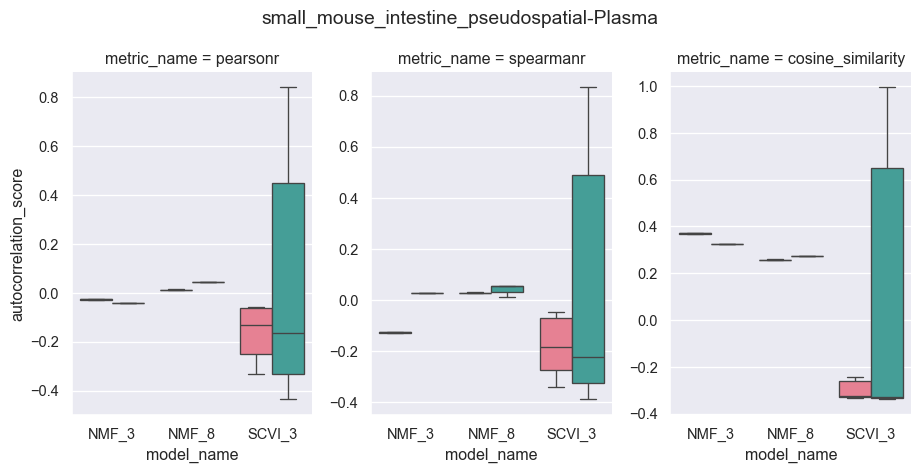

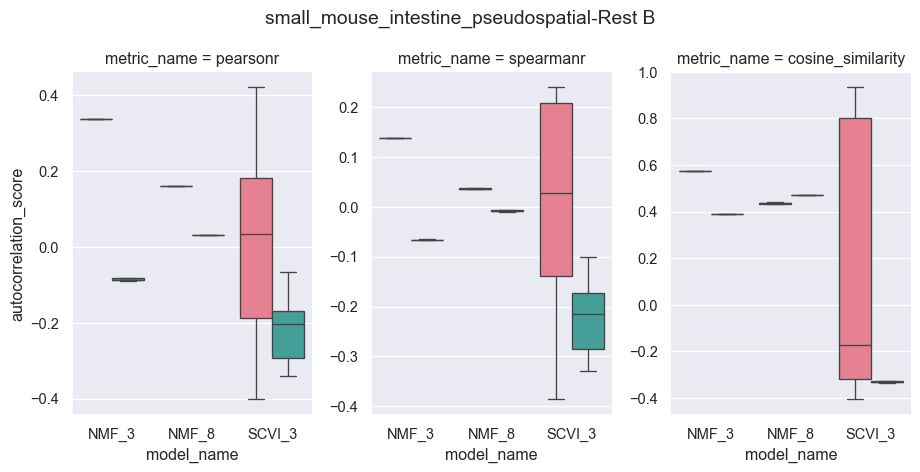

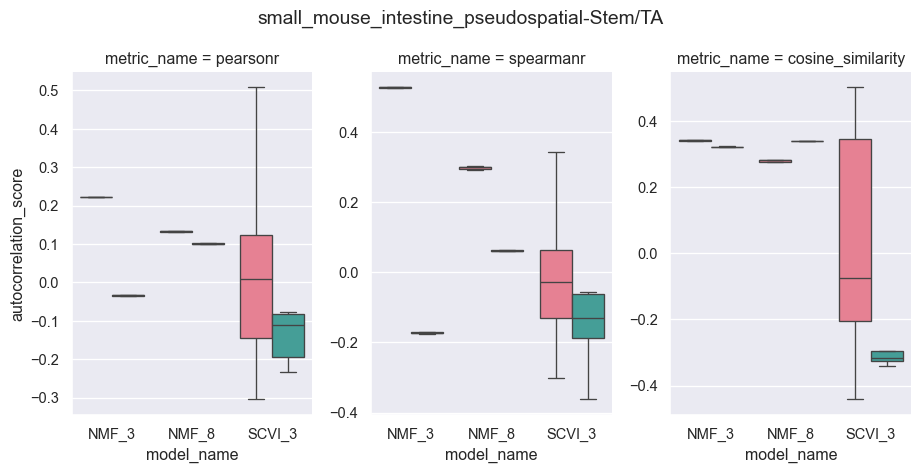

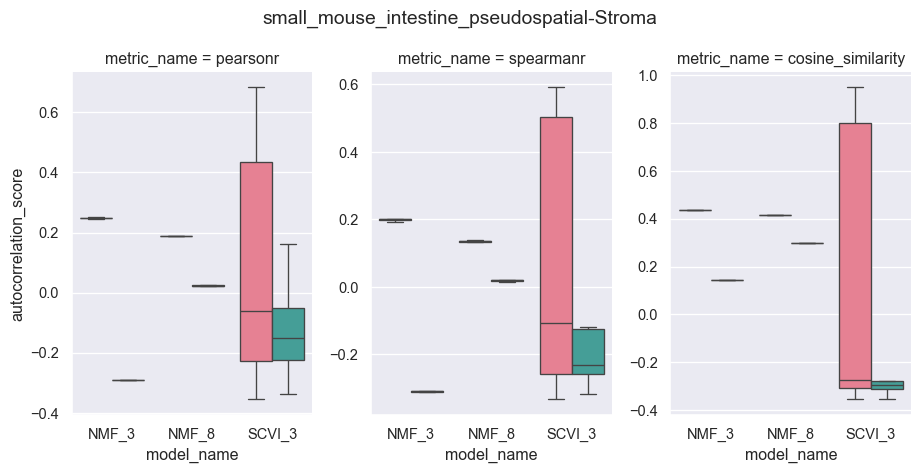

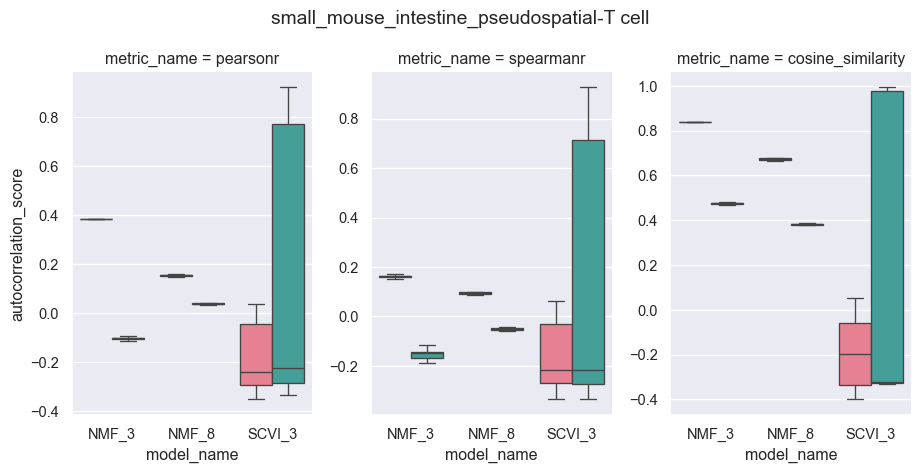

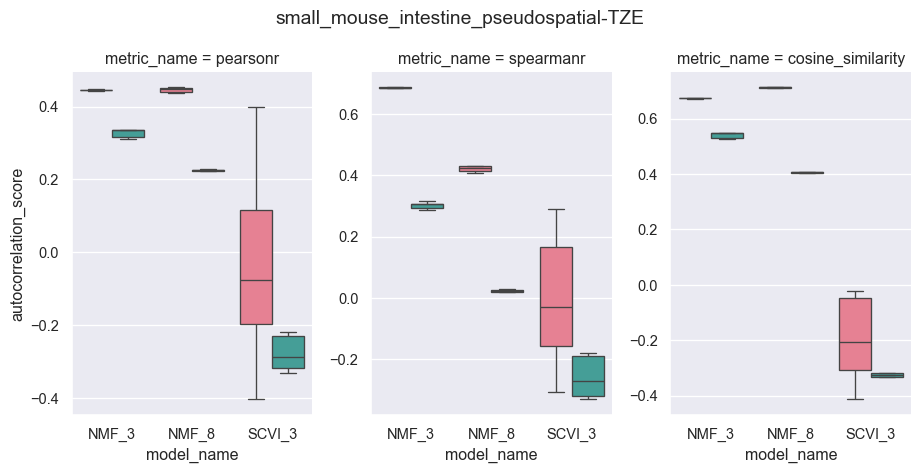

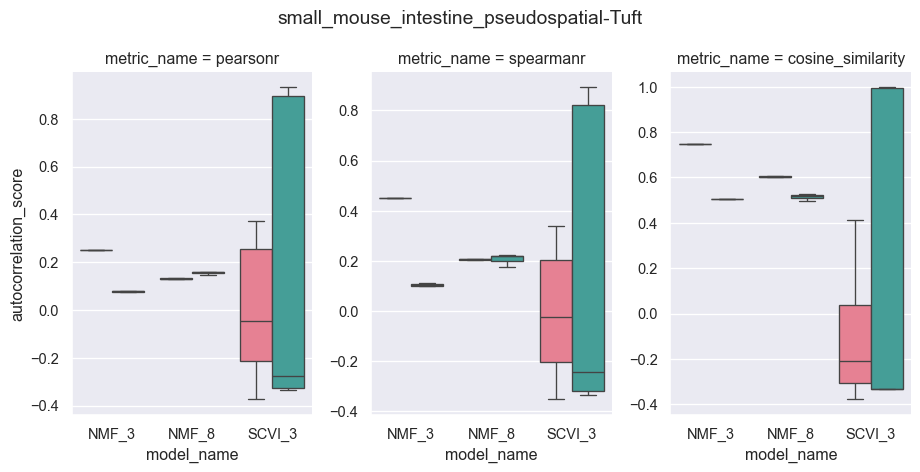

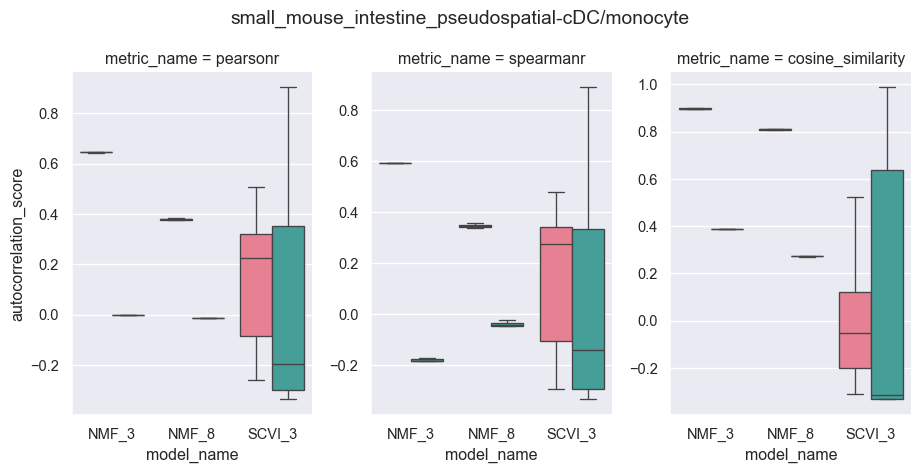

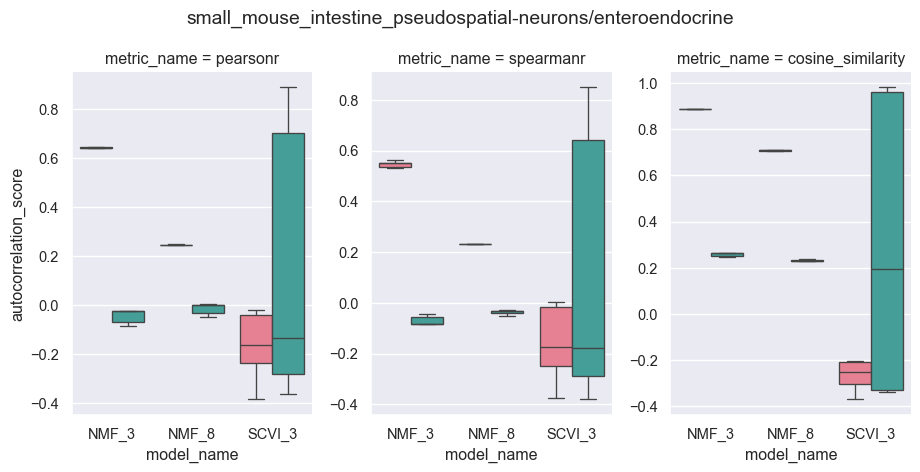

In [155]:
for (dataset_name, celltype,), autocorrelation_dataset_df in autocorrelation_df.partition_by(
    ["dataset_name", "celltype"], as_dict=True
).items():
    g = sns.FacetGrid(
        autocorrelation_dataset_df,
        col="metric_name",
        sharey=False,
        height=5,
        aspect=0.65
    )
    g.map_dataframe(
        sns.boxplot,
        x="model_name",
        y="autocorrelation_score",
        hue="model_prediction_scope",
        showfliers=False,
        palette=sns.color_palette("husl", 2),
    )
    g.fig.suptitle(f"{dataset_name}-{celltype}")
    g.fig.subplots_adjust(top=0.85)
    plt.show()

### Global Spatial Autocorrelation

In [97]:
import scipy.sparse.csgraph as csgraph


def _create_avg_interpretability_metric_fn(
    metric_fn: Callable[[NumericArray, NumericArray], float],
) -> Callable[[NumericArray, NumericArray], float]:
    def avg_interpretabilty_metric_fn(adjacency: NumericArray, features: NumericArray):
        return float(
            np.array([metric_fn(adjacency, feature) for feature in features.T]).mean()
        )

    return avg_interpretabilty_metric_fn


morans_i = _create_avg_interpretability_metric_fn(
    lambda adjacency, feature: sc.metrics.morans_i(adjacency, feature)
)

gearys_c = _create_avg_interpretability_metric_fn(
    lambda adjacency, feature: sc.metrics.gearys_c(adjacency, feature)
)


@_create_avg_interpretability_metric_fn
def laplacian_smoothness(adjacency: NumericArray, feature: NumericArray) -> float:
    """x^T L x — lower means smoother / more structured"""
    L = csgraph.laplacian(adjacency, normed=False)
    return float(feature.T @ (L @ feature))


@_create_avg_interpretability_metric_fn
def normalized_laplacian_smoothness(
    adjacency: NumericArray, feature: NumericArray
) -> float:
    """Normalized smoothness (scale-invariant)"""
    L = csgraph.laplacian(adjacency, normed=True)
    return float(feature.T @ (L @ feature))


def build_interpretability_metric_registry() -> dict[
    str, Callable[[NumericArray, NumericArray], float]
]:
    return {
        "morans_i": morans_i,
        "gearys_c": gearys_c,
        #"lap_smoothness": laplacian_smoothness,
        #"lap_smoothness_norm": normalized_laplacian_smoothness,
    }

In [104]:
@dataclass
class ExtendedCelltypeDimension:
    celltype: CelltypeDimension
    ajdacency_matrix: NDArray[number]


n_neighbours = 10
extended_celltypes = [
    ExtendedCelltypeDimension(
        celltype,
        kneighbors_graph(celltype.pca_embedding, n_neighbors=n_neighbours),
    )
    for celltype in results.celltypes
]

In [137]:
def make_interpretability_metric_evaluator(
    metric_registry: dict[str, Callable[[NDArray[number], NDArray[number]], float]],
    extended_celltypes: list[ExtendedCelltypeDimension],
) -> MetricResultFn:
    def evaluate_interpretability_metrics(result: ResultRecord) -> MetricResult:
        eps = 1e-8
        return [
            {
                "metric_name": metric_name,
                "global_model_results": metric_fn(
                    extended_celltypes[result.celltype_id].ajdacency_matrix,
                    result.global_model_embedding + eps,
                ),
                "celltype_model_results": metric_fn(
                    extended_celltypes[result.celltype_id].ajdacency_matrix,
                    result.celltype_model_embedding + eps,
                ),
            }
            for metric_name, metric_fn in metric_registry.items()
        ]

    return evaluate_interpretability_metrics

In [113]:
adj = extended_celltypes[24].ajdacency_matrix
adj.shape

(38, 38)

In [118]:
build_interpretability_metric_registry()["morans_i"](adj, np.arange(38).astype(np.float64))

TypeError: Unsupported type <class 'numpy.float64'>

In [138]:
interpretability_df = construct_result_table(
    results,
    extract_results_fn=make_interpretability_metric_evaluator(
        metric_registry=build_interpretability_metric_registry(),
        extended_celltypes=extended_celltypes,
    ),
).unpivot(
    index=["metric_name", "dataset_name", "celltype", "sample_id", "model_name"],
    variable_name="model_prediction_scope",
    value_name="interpretability_score",
)
interpretability_df

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

metric_name,dataset_name,celltype,sample_id,model_name,model_prediction_scope,interpretability_score
str,str,str,i64,str,str,f64
"""morans_i""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_results""",0.52521
"""gearys_c""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_results""",0.425223
"""morans_i""","""small_mouse_intestine_spatial""","""Blood vasc.""",0,"""NMF_3""","""global_model_results""",0.28177
"""gearys_c""","""small_mouse_intestine_spatial""","""Blood vasc.""",0,"""NMF_3""","""global_model_results""",0.543036
"""morans_i""","""small_mouse_intestine_spatial""","""Glial""",0,"""NMF_3""","""global_model_results""",0.05346
…,…,…,…,…,…,…
"""gearys_c""","""small_mouse_intestine_pseudosp…","""Tuft""",9,"""SCVI_3""","""celltype_model_results""",0.405085
"""morans_i""","""small_mouse_intestine_pseudosp…","""cDC/monocyte""",9,"""SCVI_3""","""celltype_model_results""",0.03232
"""gearys_c""","""small_mouse_intestine_pseudosp…","""cDC/monocyte""",9,"""SCVI_3""","""celltype_model_results""",0.730459


In [46]:
interpretability_df.pivot(values="interpretability_score", columns=["metric_name", "model_prediction_scope"])

dataset_name,celltype,sample_id,model_name,"{""morans_i"",""global_model_results""}","{""gearys_c"",""global_model_results""}","{""lap_smoothness"",""global_model_results""}","{""lap_smoothness_norm"",""global_model_results""}","{""morans_i"",""celltype_model_results""}","{""gearys_c"",""celltype_model_results""}","{""lap_smoothness"",""celltype_model_results""}","{""lap_smoothness_norm"",""celltype_model_results""}"
str,str,i64,str,f64,f64,f64,f64,f64,f64,f64,f64
"""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""",0.522746,0.419754,27.730243,-18.019064,0.672539,0.255612,470.64627,-48.874724
"""small_mouse_intestine_spatial""","""Blood vasc.""",0,"""NMF_3""",0.28177,0.543036,0.005042,-0.284809,0.471065,0.413089,446.940088,-33.289578
"""small_mouse_intestine_spatial""","""Glial""",0,"""NMF_3""",0.05346,0.651051,0.016692,-0.039478,0.05296,0.715128,117.649958,-25.122211
"""small_mouse_intestine_spatial""","""Goblet""",0,"""NMF_3""",0.482215,0.277179,-7.554263,-13.921011,0.431172,0.35859,80.888295,-10.650392
"""small_mouse_intestine_spatial""","""Lymphatic""",0,"""NMF_3""",0.199758,0.551342,0.414494,-0.394235,0.205774,0.624054,467.893677,20.041343
…,…,…,…,…,…,…,…,…,…,…,…
"""small_mouse_intestine_pseudosp…","""T cell""",9,"""NMF_8""",0.025357,0.803714,0.001733,-0.000627,0.010862,0.709582,6.608146,-1.201476
"""small_mouse_intestine_pseudosp…","""TZE""",9,"""NMF_8""",0.047991,0.665755,-2.708216,-1.819859,0.025197,0.654324,42.396276,-5.507458
"""small_mouse_intestine_pseudosp…","""Tuft""",9,"""NMF_8""",0.091144,0.7651,0.059879,-0.00921,0.207825,0.676543,11.174527,-0.188329


In [145]:
interpretability_df

metric_name,dataset_name,celltype,sample_id,model_name,model_prediction_scope,interpretability_score
str,str,str,i64,str,str,f64
"""morans_i""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_results""",0.52521
"""gearys_c""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_results""",0.425223
"""morans_i""","""small_mouse_intestine_spatial""","""Blood vasc.""",0,"""NMF_3""","""global_model_results""",0.28177
"""gearys_c""","""small_mouse_intestine_spatial""","""Blood vasc.""",0,"""NMF_3""","""global_model_results""",0.543036
"""morans_i""","""small_mouse_intestine_spatial""","""Glial""",0,"""NMF_3""","""global_model_results""",0.05346
…,…,…,…,…,…,…
"""gearys_c""","""small_mouse_intestine_pseudosp…","""Tuft""",9,"""SCVI_3""","""celltype_model_results""",0.405085
"""morans_i""","""small_mouse_intestine_pseudosp…","""cDC/monocyte""",9,"""SCVI_3""","""celltype_model_results""",0.03232
"""gearys_c""","""small_mouse_intestine_pseudosp…","""cDC/monocyte""",9,"""SCVI_3""","""celltype_model_results""",0.730459


<Figure size 1920x1440 with 0 Axes>

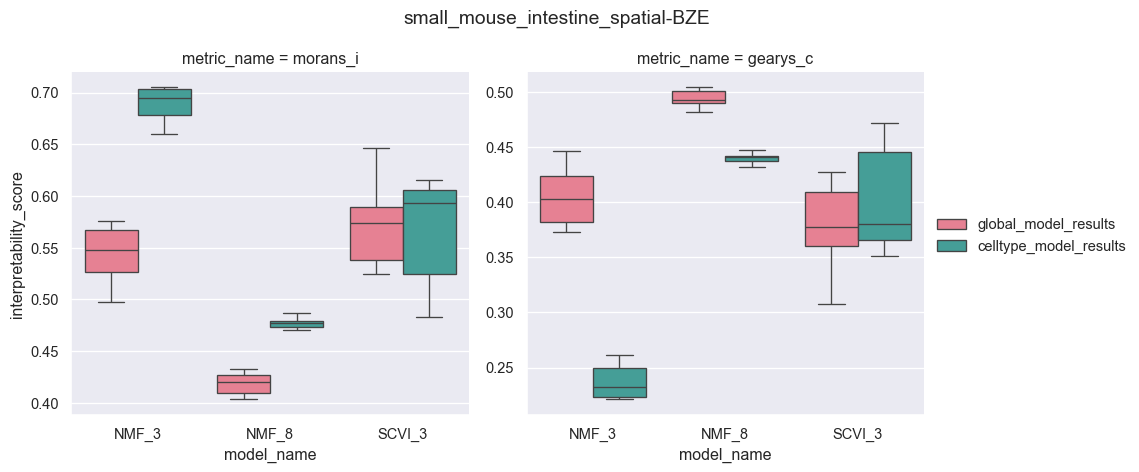

<Figure size 1920x1440 with 0 Axes>

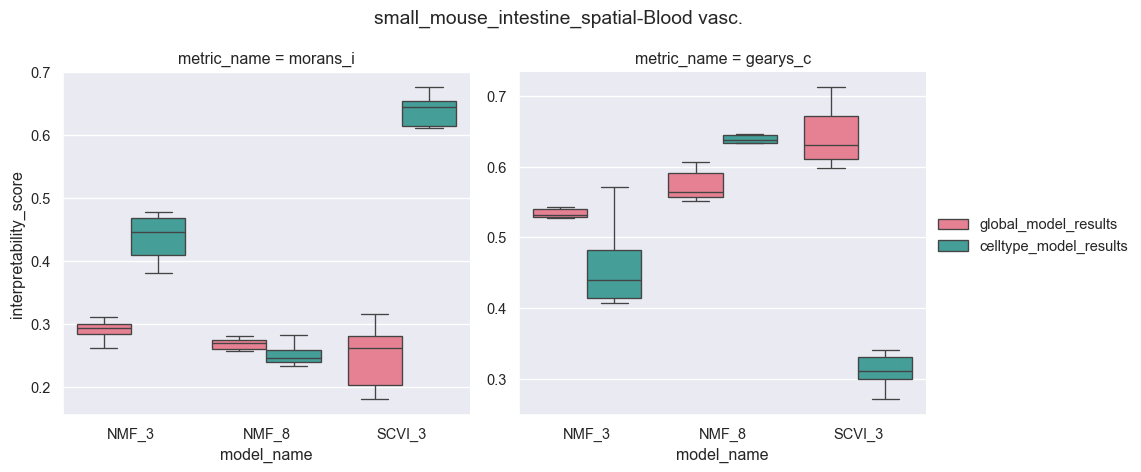

<Figure size 1920x1440 with 0 Axes>

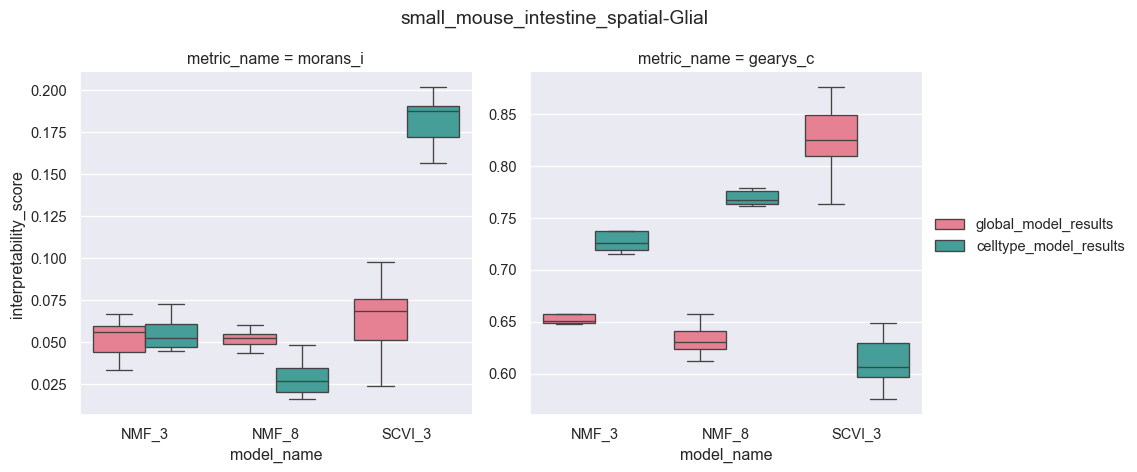

<Figure size 1920x1440 with 0 Axes>

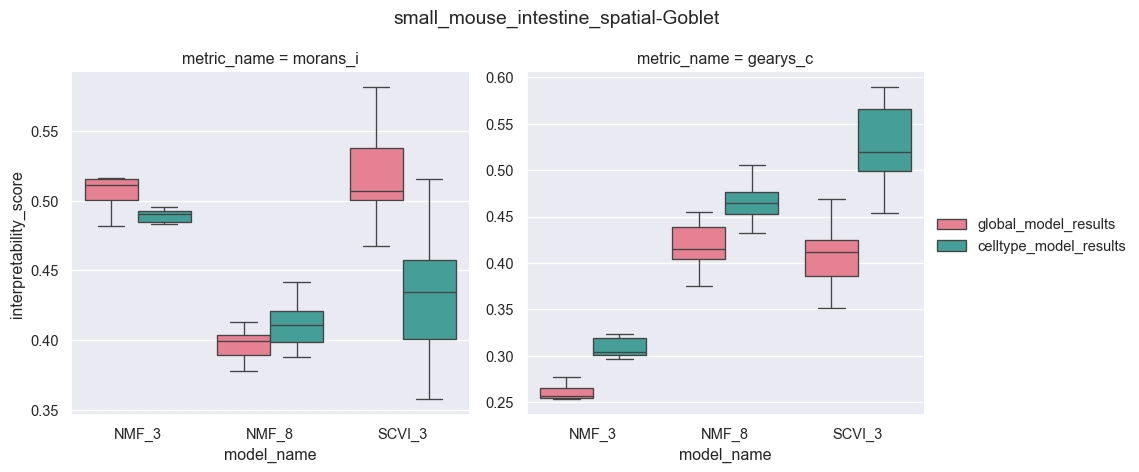

<Figure size 1920x1440 with 0 Axes>

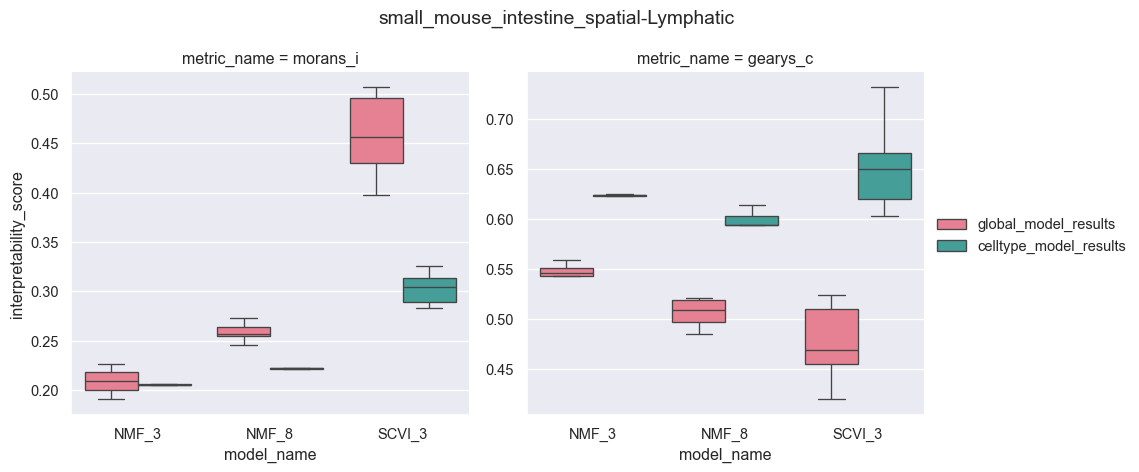

<Figure size 1920x1440 with 0 Axes>

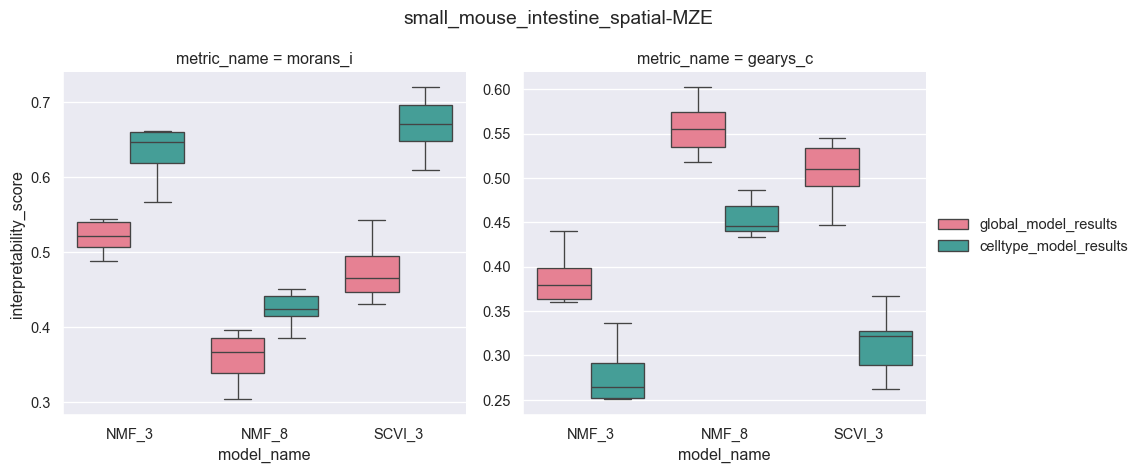

<Figure size 1920x1440 with 0 Axes>

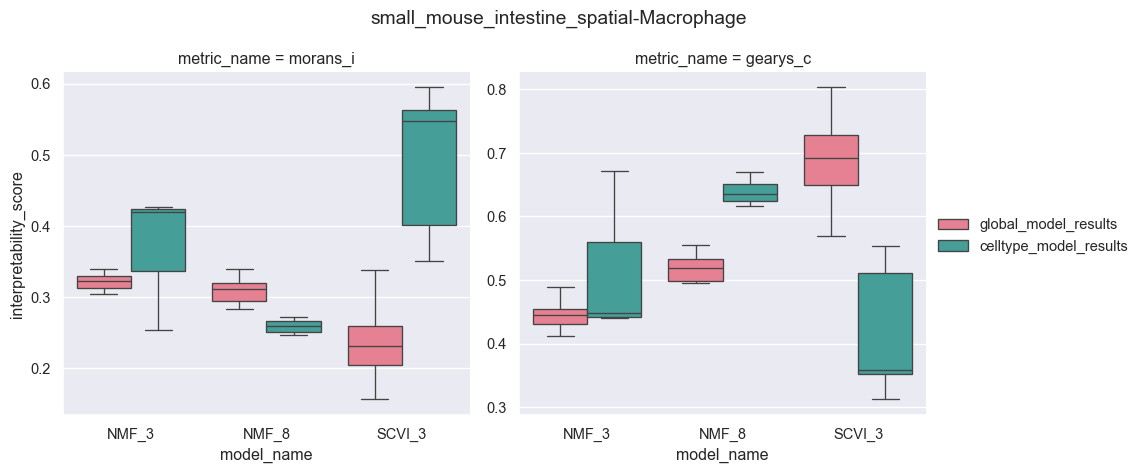

<Figure size 1920x1440 with 0 Axes>

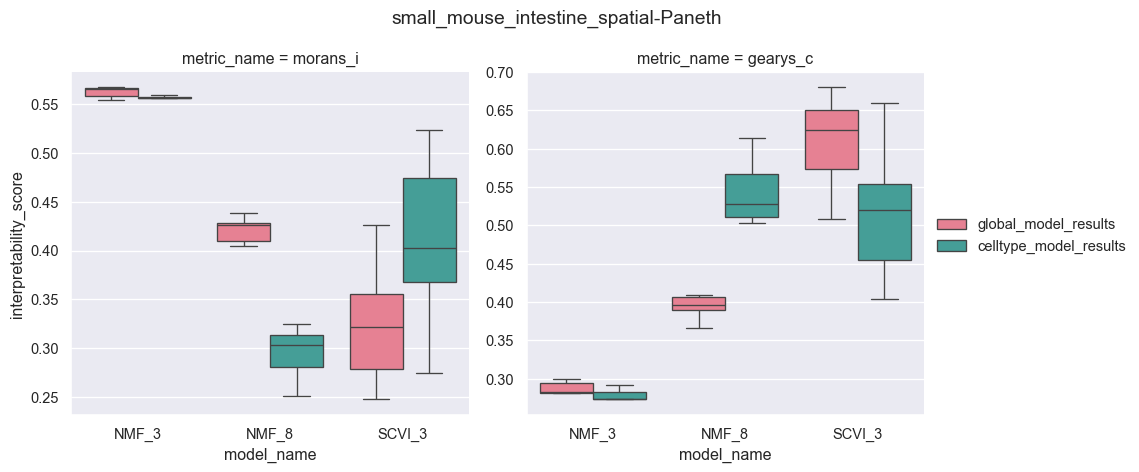

<Figure size 1920x1440 with 0 Axes>

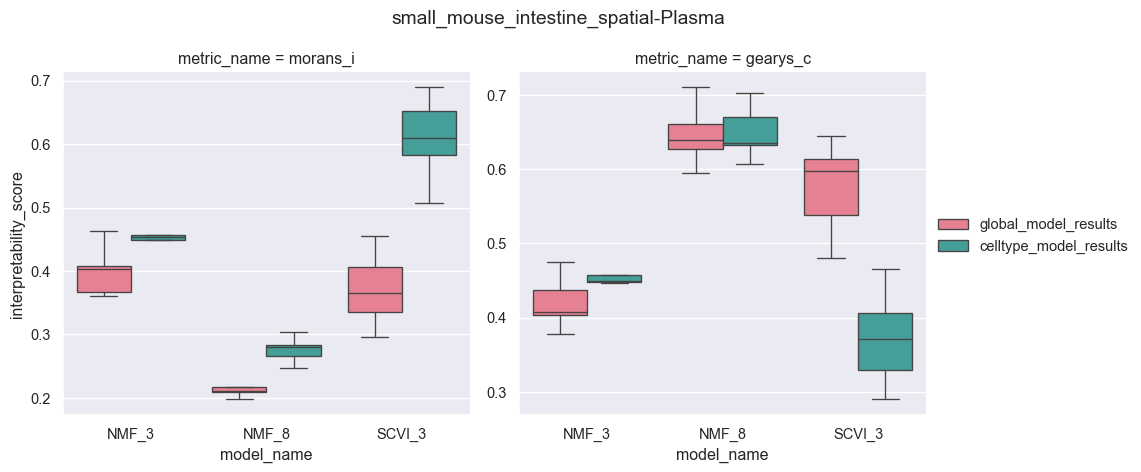

<Figure size 1920x1440 with 0 Axes>

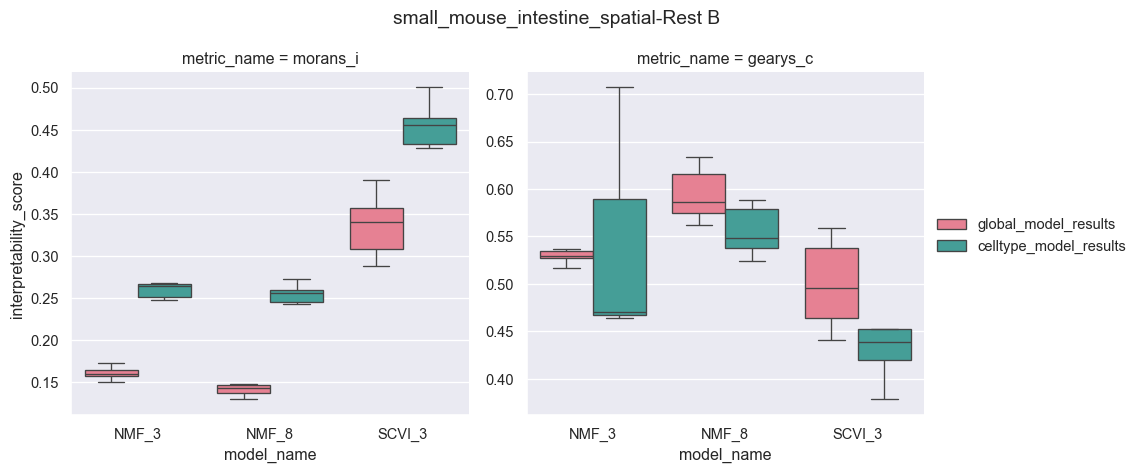

<Figure size 1920x1440 with 0 Axes>

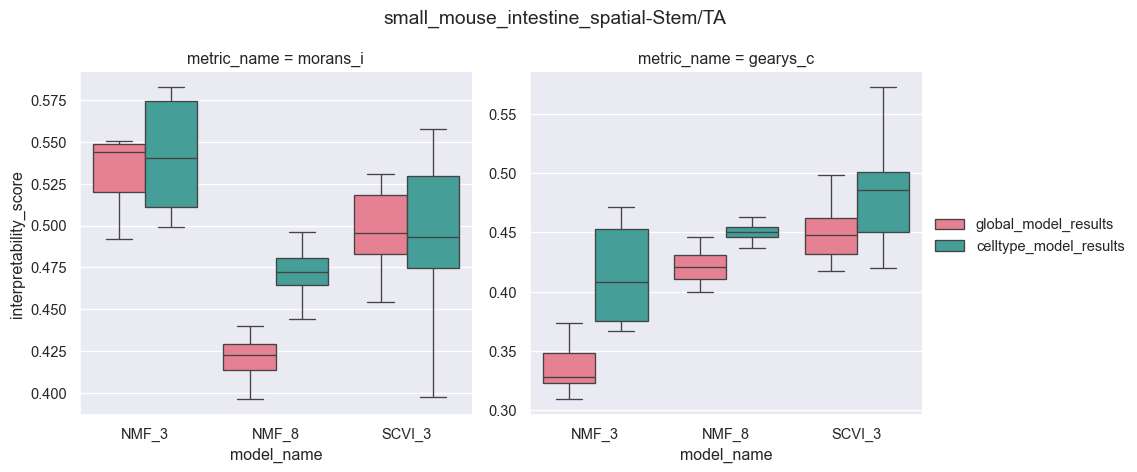

<Figure size 1920x1440 with 0 Axes>

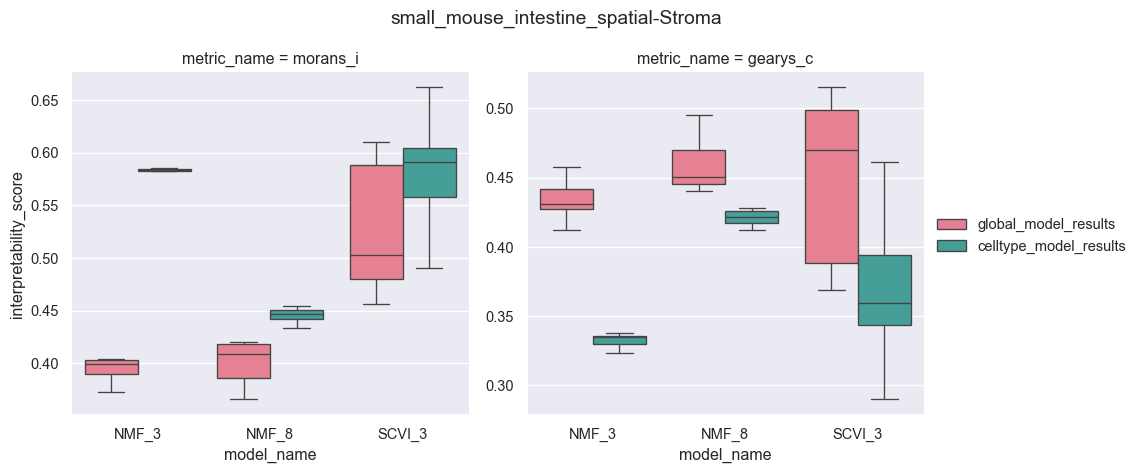

<Figure size 1920x1440 with 0 Axes>

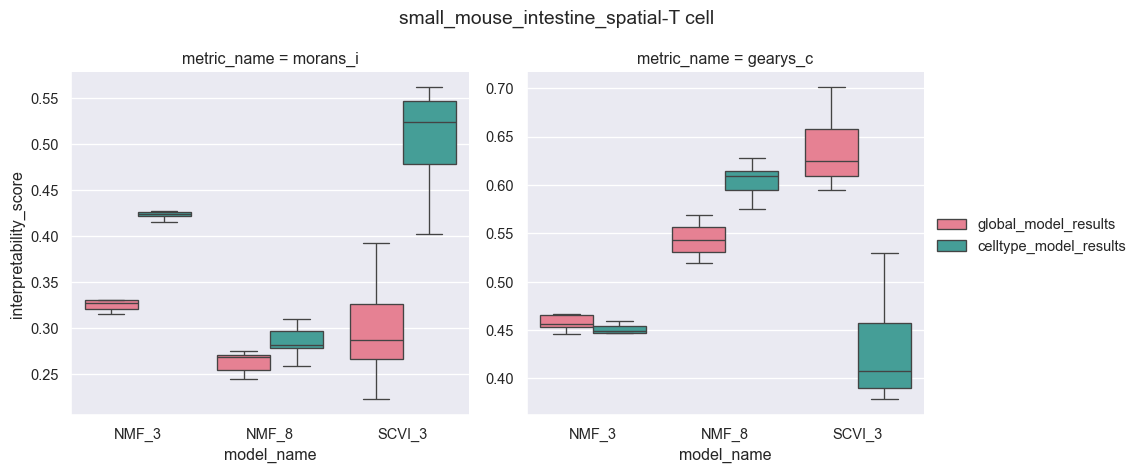

<Figure size 1920x1440 with 0 Axes>

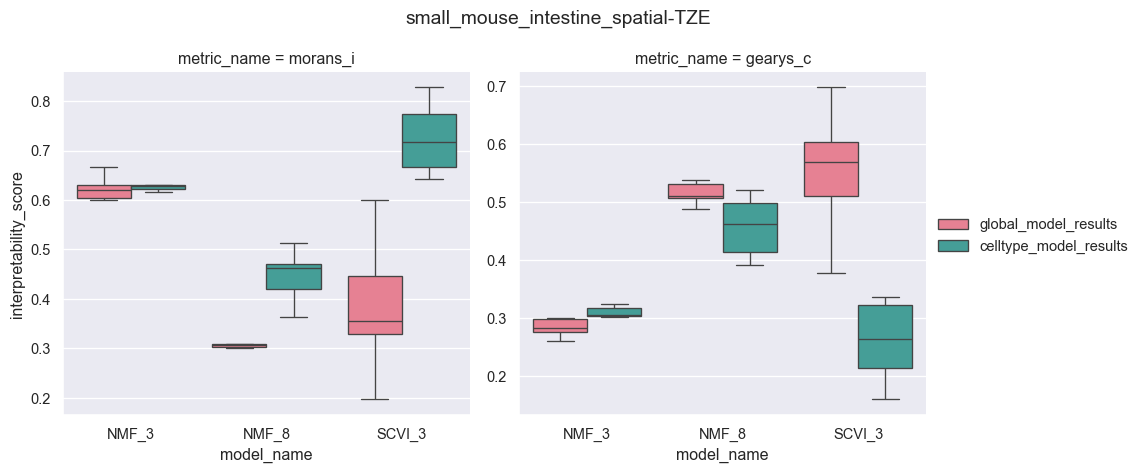

<Figure size 1920x1440 with 0 Axes>

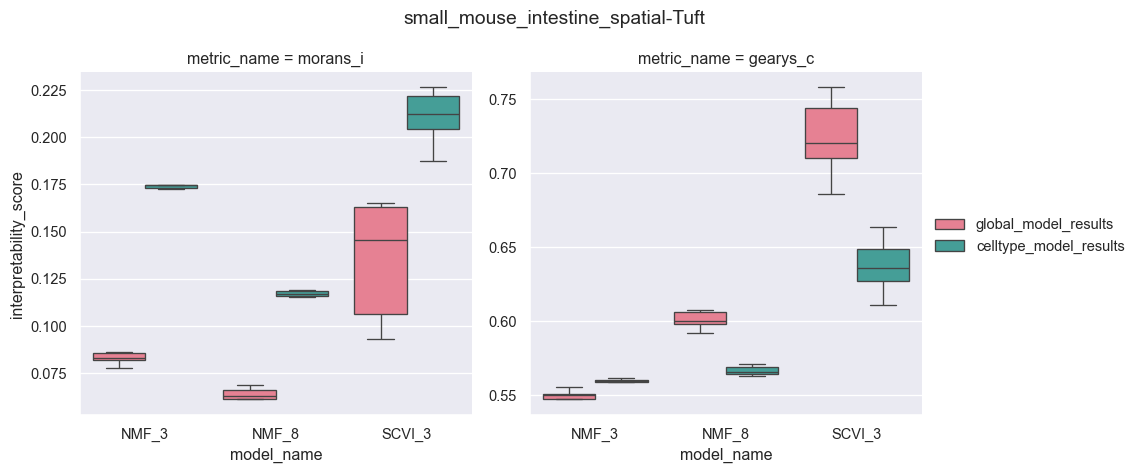

<Figure size 1920x1440 with 0 Axes>

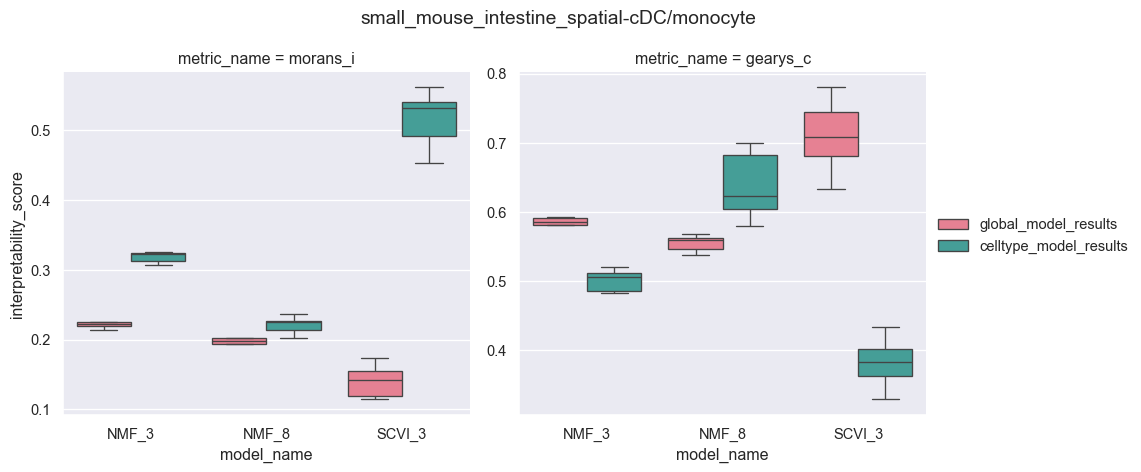

<Figure size 1920x1440 with 0 Axes>

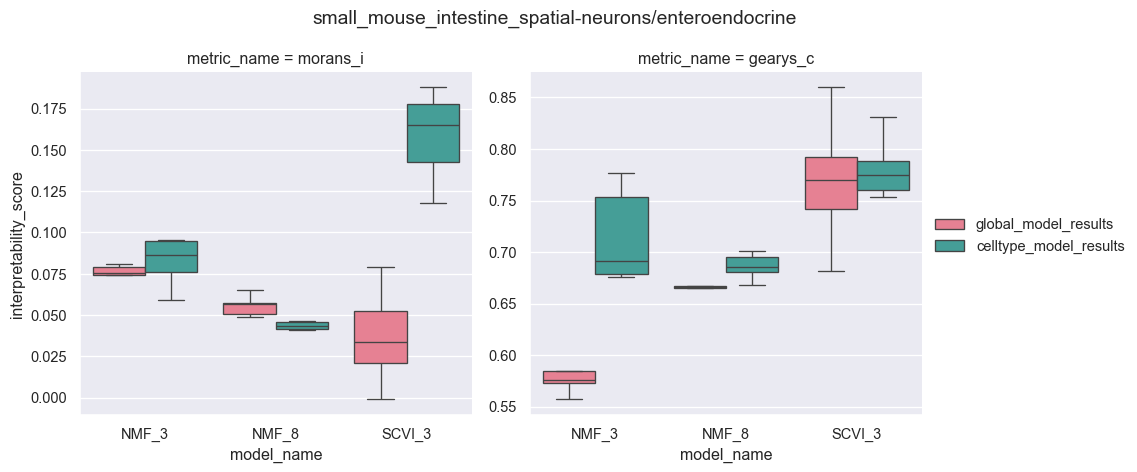

<Figure size 1920x1440 with 0 Axes>

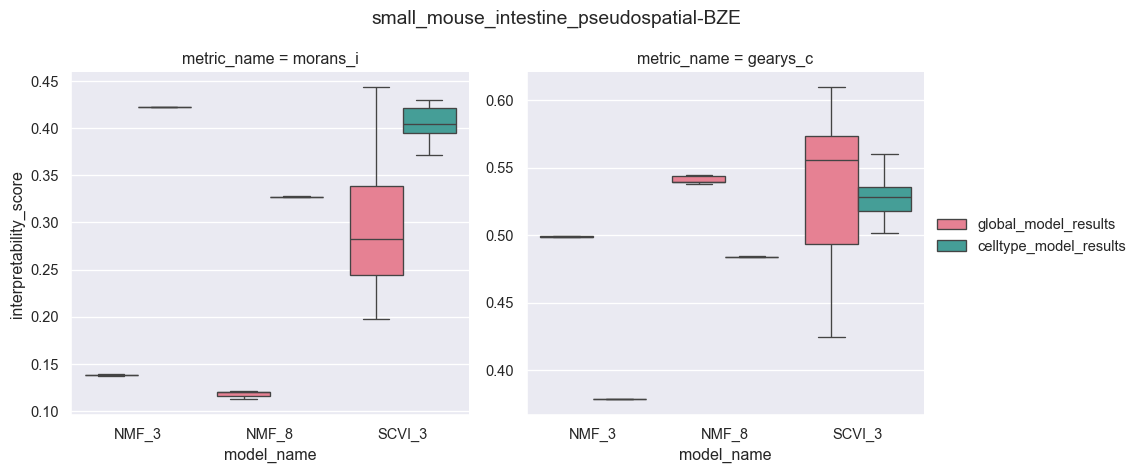

<Figure size 1920x1440 with 0 Axes>

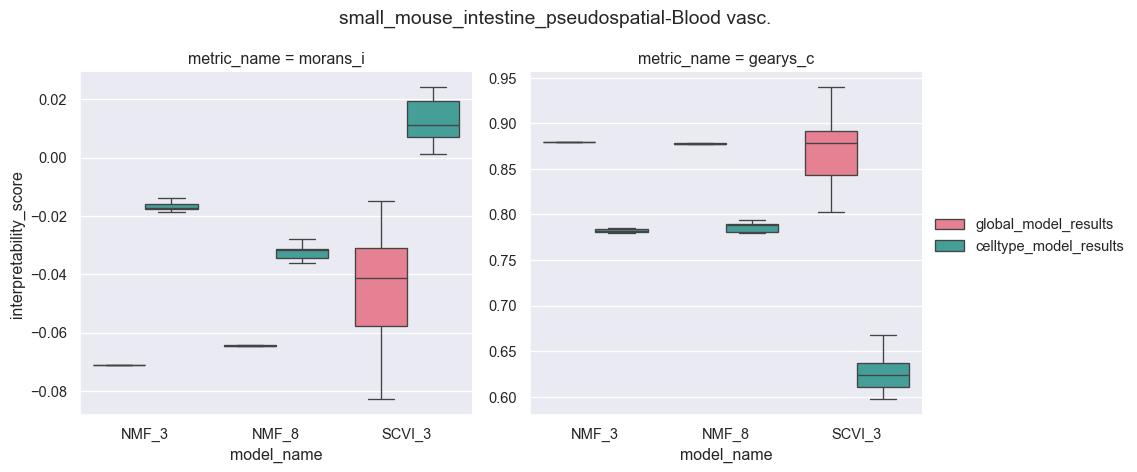

<Figure size 1920x1440 with 0 Axes>

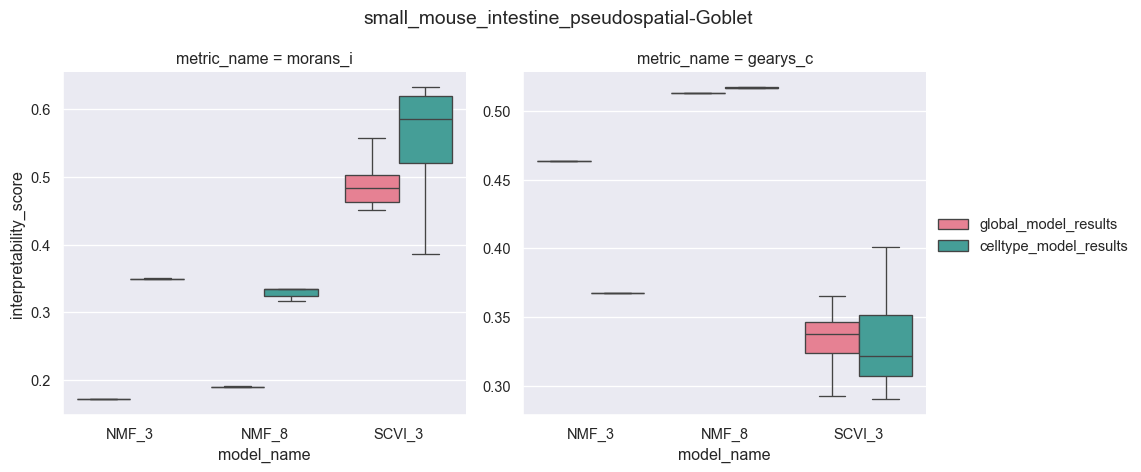

<Figure size 1920x1440 with 0 Axes>

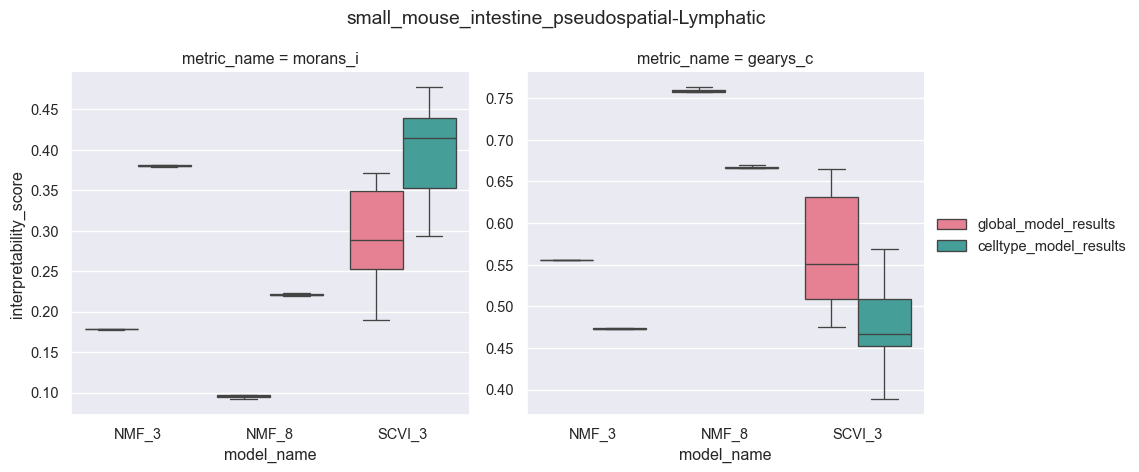

<Figure size 1920x1440 with 0 Axes>

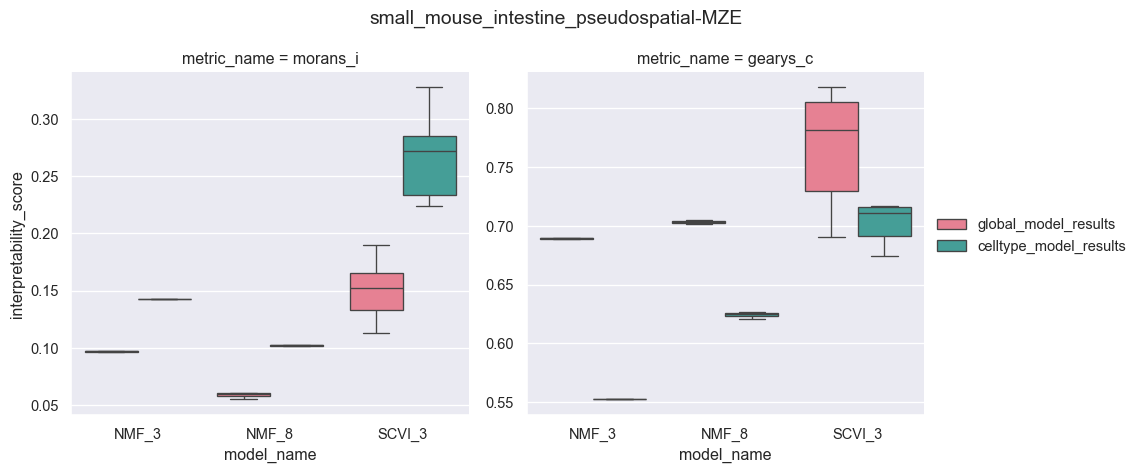

<Figure size 1920x1440 with 0 Axes>

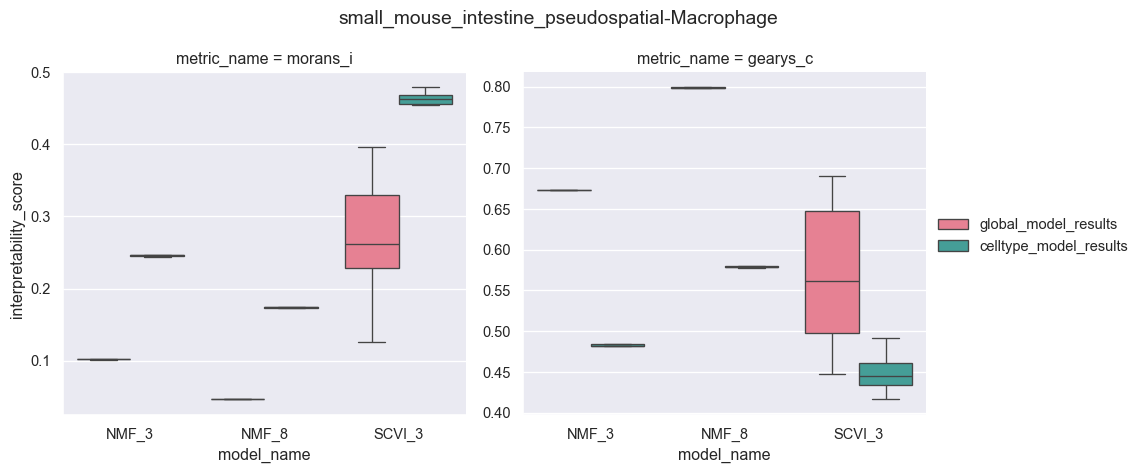

<Figure size 1920x1440 with 0 Axes>

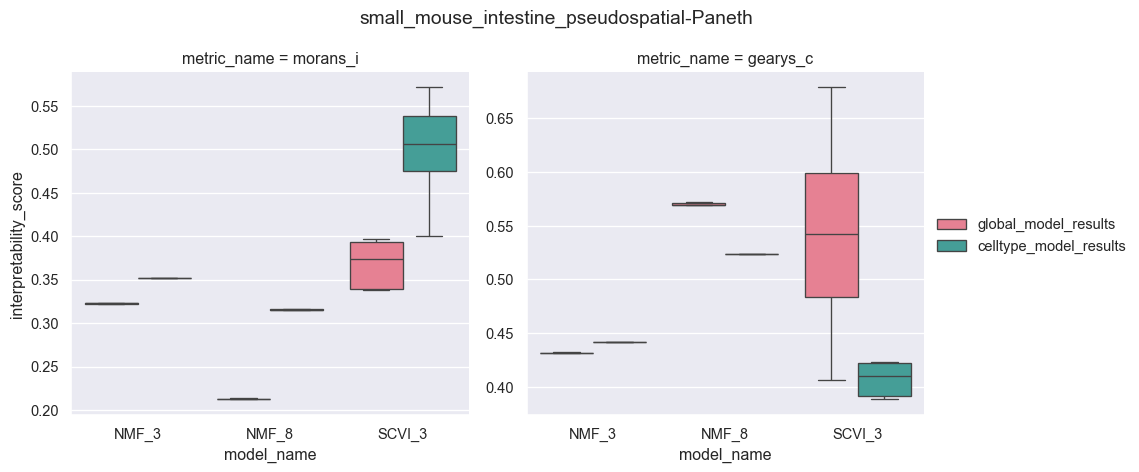

<Figure size 1920x1440 with 0 Axes>

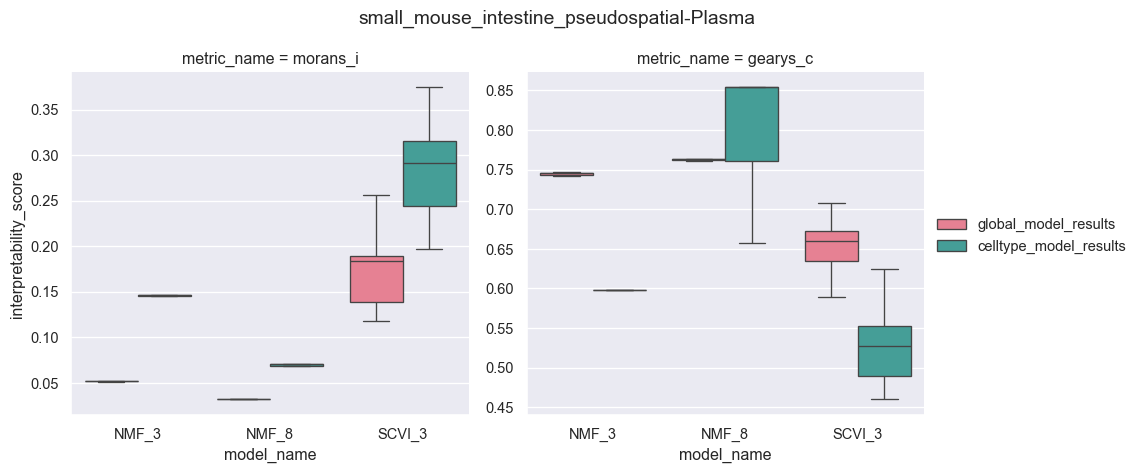

<Figure size 1920x1440 with 0 Axes>

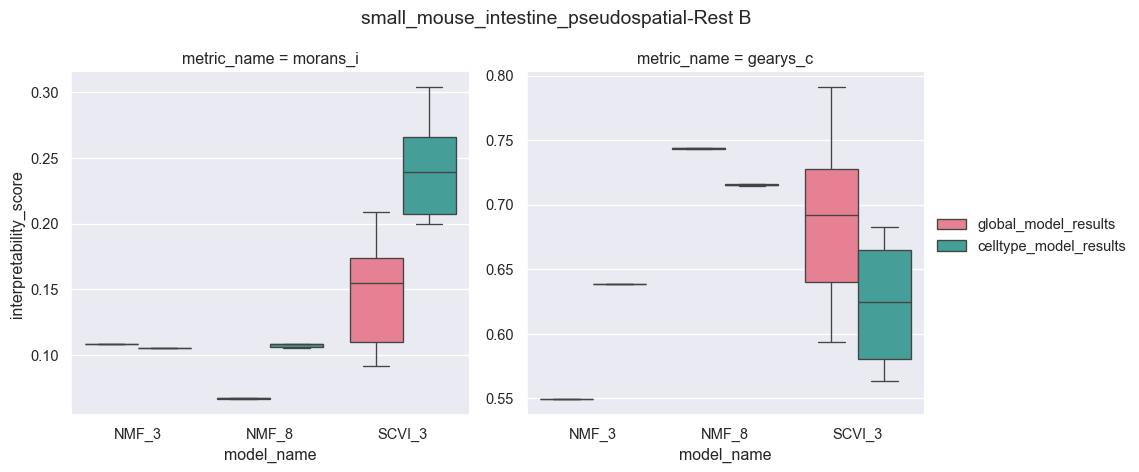

<Figure size 1920x1440 with 0 Axes>

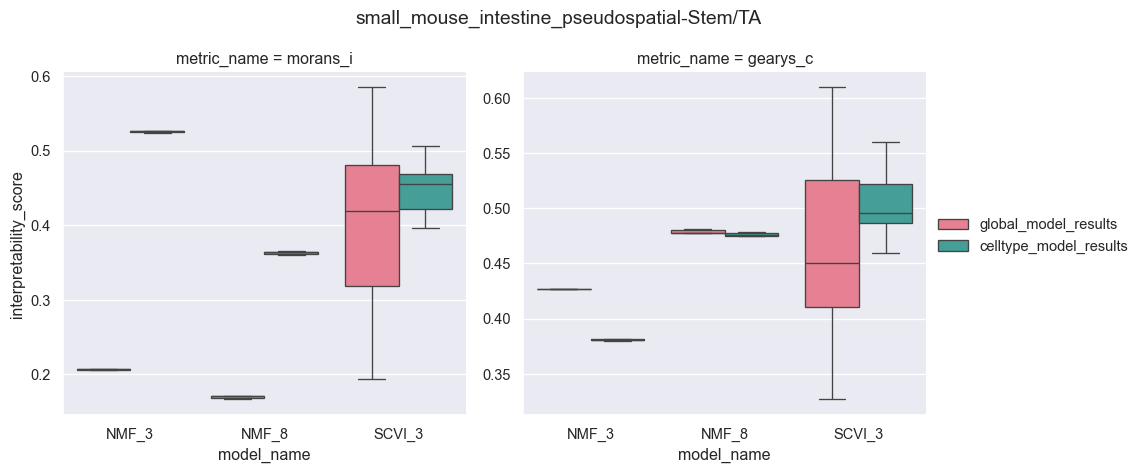

<Figure size 1920x1440 with 0 Axes>

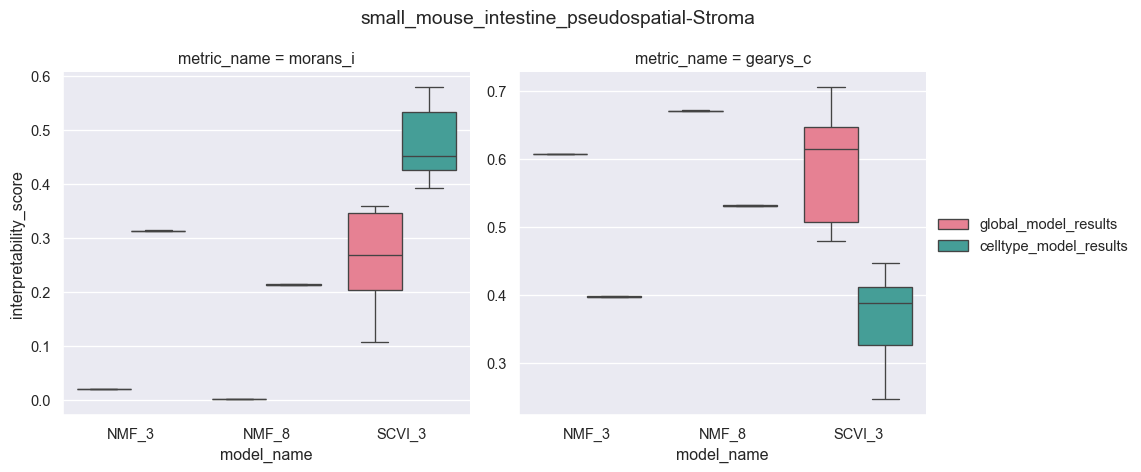

<Figure size 1920x1440 with 0 Axes>

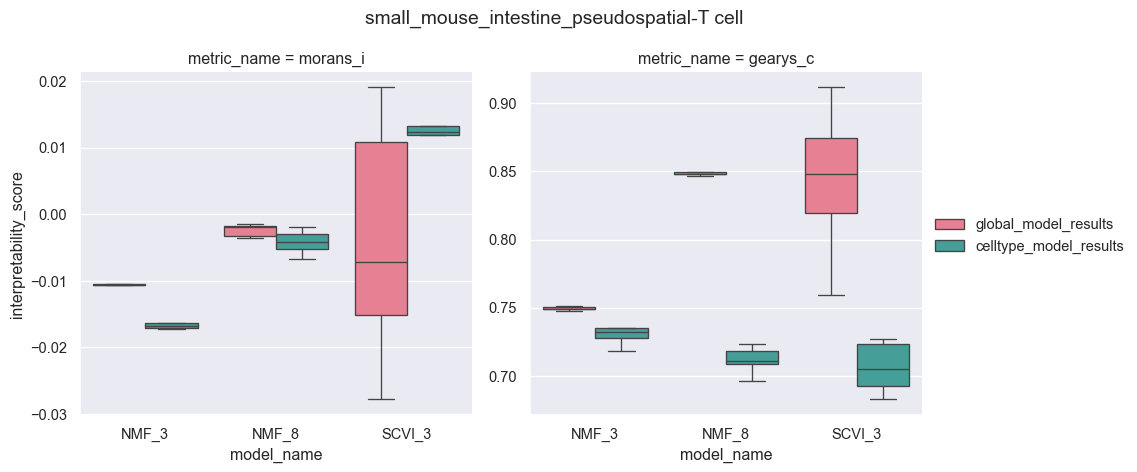

<Figure size 1920x1440 with 0 Axes>

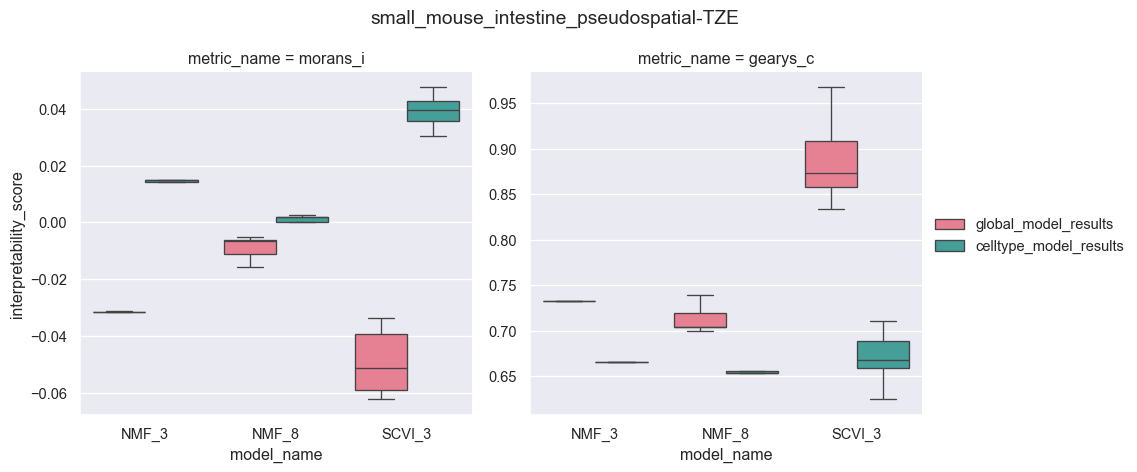

<Figure size 1920x1440 with 0 Axes>

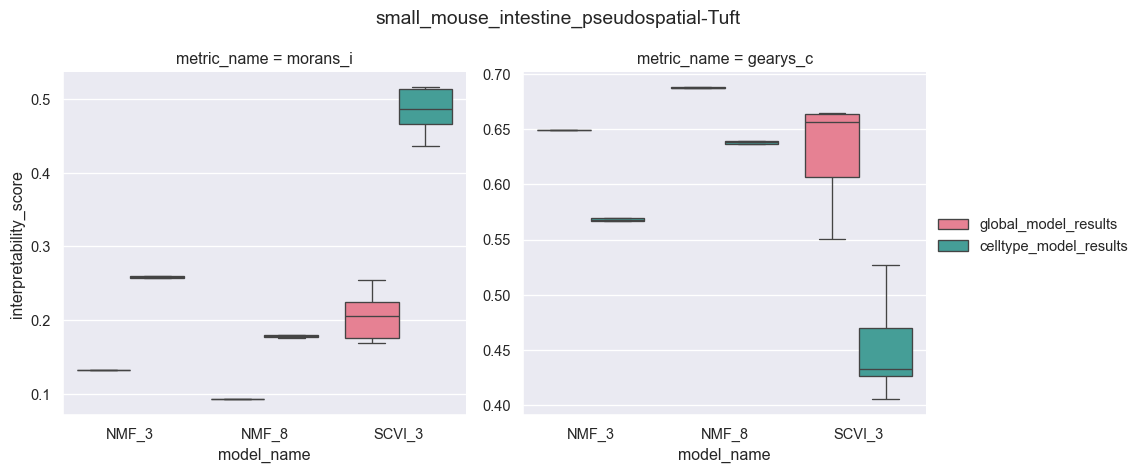

<Figure size 1920x1440 with 0 Axes>

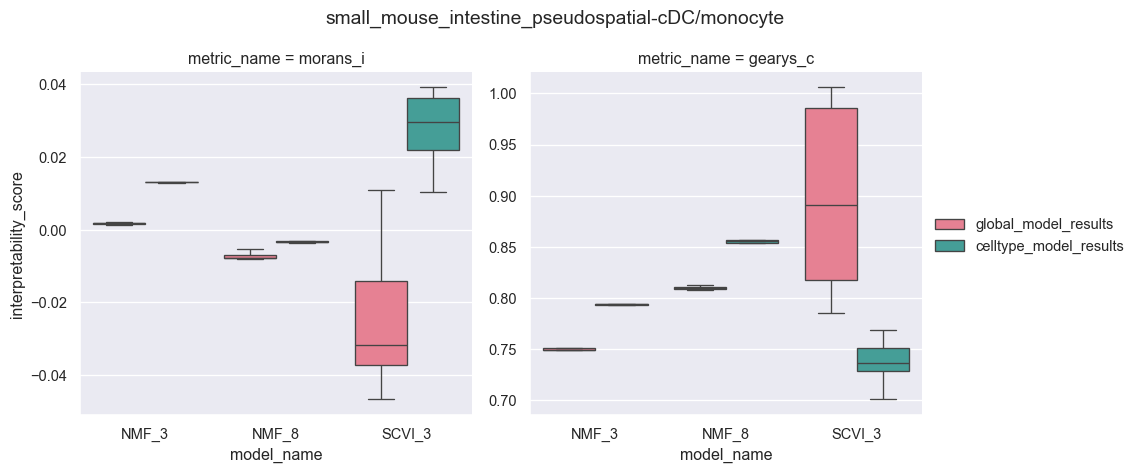

<Figure size 1920x1440 with 0 Axes>

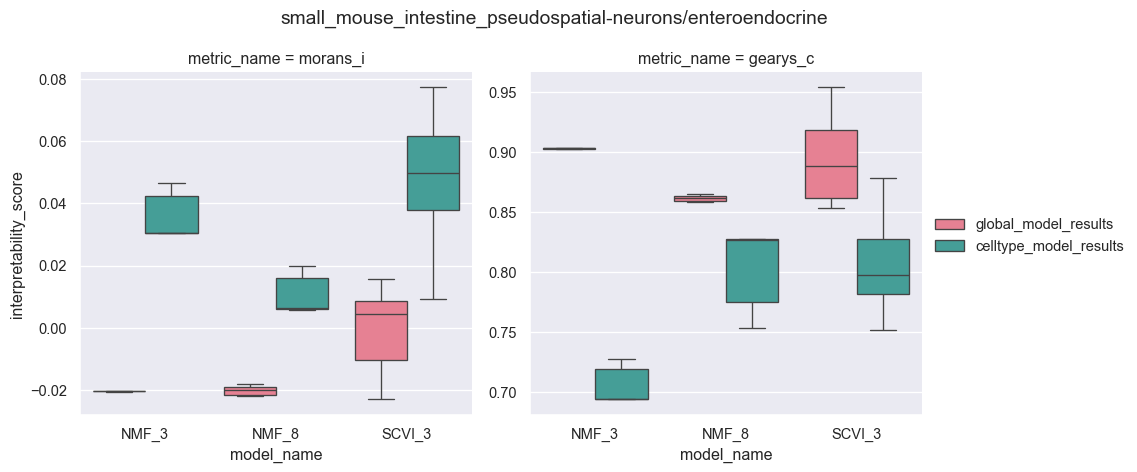

In [151]:
for (dataset_name, celltype,), interpretability_dataset_df in interpretability_df.partition_by(
    ["dataset_name", "celltype"], as_dict=True
).items():
    plt.figure(dpi=300)
    g = sns.FacetGrid(
        interpretability_dataset_df,
        col="metric_name",
        sharey=False,
        height=5,
        aspect=1,
    )
    g.map_dataframe(
        sns.boxplot,
        x="model_name",
        y="interpretability_score",
        hue="model_prediction_scope",
        showfliers=False,
        palette=sns.color_palette("husl", 2),
    )
    g.add_legend()
    g.fig.suptitle(f"{dataset_name}-{celltype}")
    g.fig.subplots_adjust(top=0.85)
    plt.show()

In [149]:
sns.set_theme(rc={"figure.dpi": 96})

<Figure size 1920x1440 with 0 Axes>

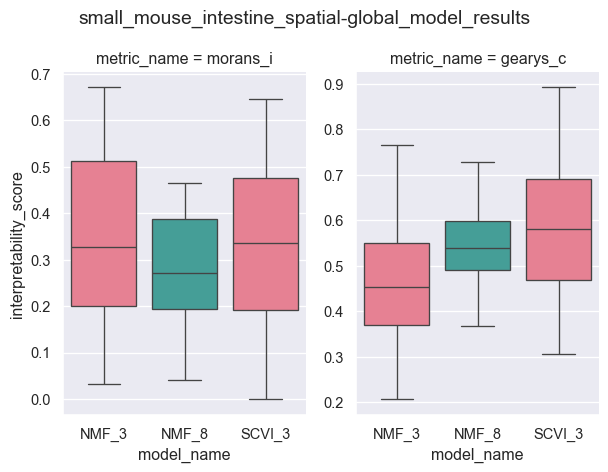

<Figure size 1920x1440 with 0 Axes>

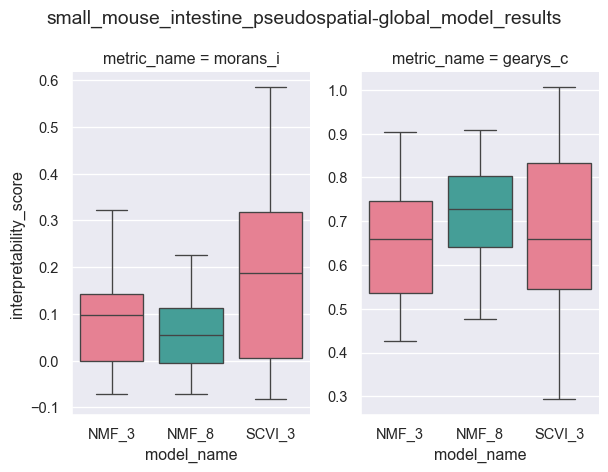

<Figure size 1920x1440 with 0 Axes>

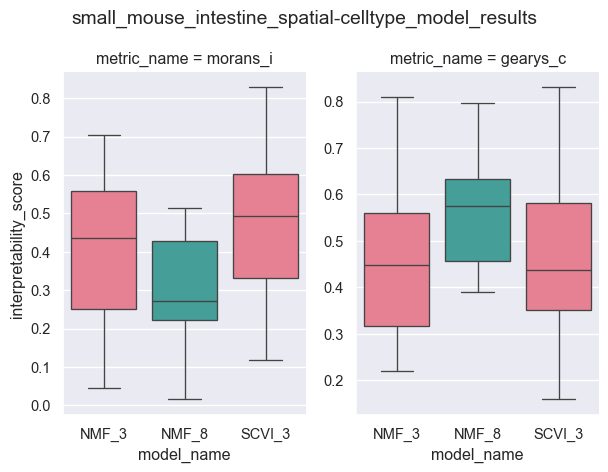

<Figure size 1920x1440 with 0 Axes>

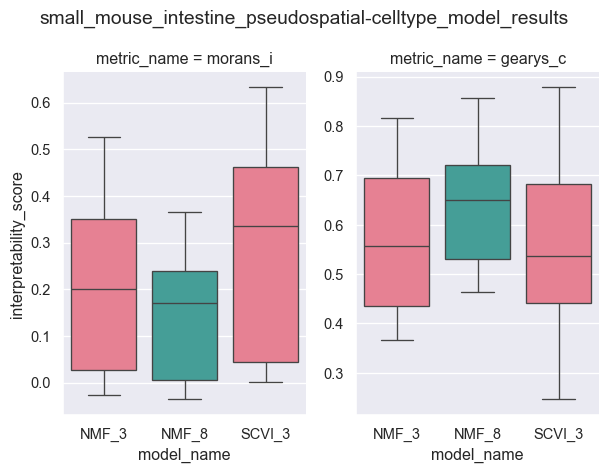

In [150]:
for (dataset_name, model_prediction_scope,), interpretability_dataset_df in interpretability_df.partition_by(
    ["dataset_name", "model_prediction_scope"], as_dict=True
).items():
    plt.figure(dpi=300)
    g = sns.FacetGrid(
        interpretability_dataset_df,
        col="metric_name",
        sharey=False,
        height=5,
        aspect=0.65,
    )
    g.map_dataframe(
        sns.boxplot,
        x="model_name",
        y="interpretability_score",
        showfliers=False,
        palette=sns.color_palette("husl", 2),
    )
    g.fig.suptitle(f"{dataset_name}-{model_prediction_scope}")
    g.fig.subplots_adjust(top=0.85)
    plt.show()